# Cell-count conditioning and marker ablation

Compare four depth-2 models, using all timepoints:

| Model | FiLM conditioning | Features passed to the head |
| --- | --- | --- |
| `gin_head_size` | None | log cell count |
| `gin_film_size` | log cell count | log cell count |
| `gin_head_size_geometry` | None | log cell count + three geometry features |
| `gin_film_size_geometry` | log cell count | log cell count + three geometry features |

The geometry features are `log_surface_area`, `log_volume`, and `log_volume_over_area`.
A shared baseline is fitted separately on each training fold using **all four global
features, including `log_num_cells`**, then subtracted from the cell-level targets.
It predicts one constant per organoid and never uses validation targets during fitting.
All four residual models share this baseline and the fitted residual target transform.
Geometry enters the additional variants only through the head; FiLM still uses N alone.

Two paired analyses follow training: effects at observed cell counts, and effects of the
same single-cell marker ablation in a fixed neighborhood while sweeping the supplied count.
A sweep changes only N in the model input: graph topology, fate, and the three geometry
features remain fixed. The subtracted baseline remains its observed-organoid value and
cancels in paired effects. This probes conditional sensitivity, not simulated growth.

The four-model experiment has completed; the post-training normalization section below
uses saved results from `20260910_164825_all_depth2_four_models_baseline_with_size`.
Changing the baseline required retraining all four variants for a fair comparison.
The [earlier two-model report](../results_experiments/size_conditioned_ablation/20260910_114029_all_depth2/RESULTS.md)
and its saved data remain available as historical results with a different baseline.

The final [observed-versus-sweep plotting section](#observed-versus-sweep-overlays)
can run independently from saved CSVs without retraining. During a full run it uses
the current experiment; in a fresh kernel, explicitly select a saved run there.

[Post-training geometric normalization](#geometric-normalization) below compares raw and dimensionless effects from saved results without retraining.

[FiLM diagnostics at LGR5-positive centers](#lgr5-film-diagnostics) include split size routes, hidden-state changes, matched-marker scaling, and factorial interactions.


In [1]:
import copy
import json
import pickle
import random
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch_geometric.data import Data

PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src').is_dir())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
DATA_ROOT = PROJECT_ROOT / 'training_data'


## Settings to review

`RUN_TRAINING` and `RUN_ABLATIONS` default to `False`. Loading data and viewing the
cohort/split diagnostics does not train anything. Enable the relevant switch only when ready.

Defaults follow the existing ablation model (Gaussian loss, edge loss, batch normalization,
residual connections, transformed-validation-MAE early stopping). **MSE below is evaluated
in physical curvature units**, separately from the early-stopping criterion. Global baseline
training retains the existing transform's training-set MAE stopping rule; it never sees the
outer validation fold during fitting. The spherical-organoid exclusion is off to preserve early
stages. Target-outlier interpolation remains enabled as in the existing experiment, so the
reported MSE uses those preprocessed targets.


In [ ]:
RUN_TRAINING = True
RUN_ABLATIONS = True

EXPERIMENT_GROUP = 'size_conditioned_ablation'
DATASET_NAME = 'after_cleanup'
TARGET_INDICES = [0]  # Gaussian curvature, one scalar target
TIMEPOINT_FILTER_MODE = 'all'
FILTER_BLACKLISTED_ORGANOIDS = True
APPLY_SPHERICITY_FILTER = True
SPHERICITY_MAX = 0.94
INTERPOLATE_TARGET_OUTLIERS = True
OUTLIER_CLIP_QUANTILES = (0.005, 0.995)

SUBTRACT_CONSTANT_GLOBAL_BASELINE = True
GEOMETRY_FEATURES = ['log_surface_area', 'log_volume', 'log_volume_over_area']
BASELINE_FEATURES = ['log_num_cells', *GEOMETRY_FEATURES]
# Feature order is explicit: the sweep and FiLM select log_num_cells, never geometry.
MODEL_GLOBAL_FEATURES = {
    'gin_head_size': ['log_num_cells'],
    'gin_film_size': ['log_num_cells'],
    'gin_head_size_geometry': ['log_num_cells', *GEOMETRY_FEATURES],
    'gin_film_size_geometry': ['log_num_cells', *GEOMETRY_FEATURES],
}
MODEL_COLORS = {
    'gin_head_size': '#2878b5', 'gin_film_size': '#d45a31',
    'gin_head_size_geometry': '#29945b', 'gin_film_size_geometry': '#9467bd',
}
BASELINE_HIDDEN_DIM = 64
BASELINE_DROPOUT = 0.1
BASELINE_LR = 3e-4
BASELINE_MAX_EPOCHS = 2000
BASELINE_PATIENCE = 30
BASELINE_SEED = 4200

ANALYSIS_MODE = 'folded'  # 'folded' or 'single_split'
N_FOLDS = 5
VAL_FRAC = 0.2
SPLIT_SEED = 42
MODEL_SEEDS = [42, 43, 44]
MODEL_NAMES = list(MODEL_GLOBAL_FEATURES)
NUM_LAYERS = 2
HIDDEN_DIM = 256
FILM_HIDDEN_DIM = 16
FILM_SIZE_IN_HEAD = True
DROPOUT = 0.1
NORM = 'batch'
RESIDUAL = True
LR = 3e-4
LOSS_NAME = 'gaussian'
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 128
MAX_EPOCHS = 500
PATIENCE = 30
NUM_WORKERS = 4
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EDGE_LOSS_WEIGHT = 0.20
EDGE_LOSS_PARAMS = dict(weighted=False, alpha=2.0, normalize_by='graph_std', clip_weight=4.0)

N_SIZE_BINS = 5
BOOTSTRAP_SAMPLES = 1000
MIN_ORGANOIDS_PER_EFFECT = 5
ABLATION_HOPS = [1, 2]  # exact rings; optionally add 0 for center ablation
ABLATION_CENTERS_PER_ORGANOID = 30
SWEEP_CENTERS_PER_ORGANOID = 5
ABLATION_SEED = 1701
PERTURB_BATCH_SIZE = 128
SWEEP_TRAIN_QUANTILES = (0.10, 0.90)
SWEEP_N_POINTS = 9
LOCAL_SIZE_FOLD_CHANGE = 2.0  # diagnostic flag, not a changing-cohort filter
# One uniformly selected source-positive cell per center/marker/ring, fixed across models and N.
# No outcome-dependent outlier trimming or marker-pair top-ups; report available support.

RUN_NAME = datetime.now().strftime('%Y%m%d_%H%M%S') + f'_all_depth{NUM_LAYERS}_four_models_baseline_with_size'
SAVE_DIR = PROJECT_ROOT / 'results_experiments' / EXPERIMENT_GROUP / RUN_NAME


In [3]:
SETTINGS = {key: value for key, value in list(globals().items())
            if key.isupper() and isinstance(value, (str, int, float, bool, list, tuple, dict, Path))}
print(json.dumps(SETTINGS, indent=2, default=str))
print(f'Planned curvature-model fits: {(N_FOLDS if ANALYSIS_MODE == "folded" else 1) * len(MODEL_SEEDS) * len(MODEL_NAMES)}')
print('Plus one shared size + geometry baseline per fold. No training has started.')


{
  "PROJECT_ROOT": "/home/fmoller/Projects/LearningOrganoids/GraphNN",
  "DATA_ROOT": "/home/fmoller/Projects/LearningOrganoids/GraphNN/training_data",
  "RUN_TRAINING": true,
  "RUN_ABLATIONS": true,
  "EXPERIMENT_GROUP": "size_conditioned_ablation",
  "DATASET_NAME": "after_cleanup",
  "TARGET_INDICES": [
    0
  ],
  "TIMEPOINT_FILTER_MODE": "all",
  "FILTER_BLACKLISTED_ORGANOIDS": true,
  "APPLY_SPHERICITY_FILTER": true,
  "SPHERICITY_MAX": 0.92,
  "INTERPOLATE_TARGET_OUTLIERS": true,
  "OUTLIER_CLIP_QUANTILES": [
    0.005,
    0.995
  ],
  "SUBTRACT_CONSTANT_GLOBAL_BASELINE": true,
  "GEOMETRY_FEATURES": [
    "log_surface_area",
    "log_volume",
    "log_volume_over_area"
  ],
  "BASELINE_FEATURES": [
    "log_num_cells",
    "log_surface_area",
    "log_volume",
    "log_volume_over_area"
  ],
  "MODEL_GLOBAL_FEATURES": {
    "gin_head_size": [
      "log_num_cells"
    ],
    "gin_film_size": [
      "log_num_cells"
    ],
    "gin_head_size_geometry": [
      "log_num_cells

## Load all timepoints and inspect the cohort


In [4]:
from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import attach_metadata_to_graphs, load_aux_metadata_for_dir, load_marker_names_from_dir
from src.data.filters import filter_graphs_by_blacklist, load_graph_blacklist_from_dir, filter_graphs_by_sphericity
from src.data.preprocessing import interpolate_target_outliers_from_neighbors
from src.data.splits import graph_metadata_key

assert TIMEPOINT_FILTER_MODE == 'all', 'This experiment includes all timepoints.'
assert TARGET_INDICES == [0], 'The analysis below expects scalar Gaussian curvature.'
data_dir = DATA_ROOT / DATASET_NAME
graphs = load_graph_dataset_from_dir(str(data_dir))
attach_metadata_to_graphs(graphs, load_aux_metadata_for_dir(str(data_dir)), exclude_keys=None)
graphs = select_graph_targets(graphs, target_indices=TARGET_INDICES, inplace=False)
marker_names = load_marker_names_from_dir(str(data_dir))
if marker_names is None:
    marker_names = [f'marker_{i}' for i in range(graphs[0].x.shape[1])]
if FILTER_BLACKLISTED_ORGANOIDS:
    graphs = filter_graphs_by_blacklist(graphs, load_graph_blacklist_from_dir(data_dir), print_summary=True)
if APPLY_SPHERICITY_FILTER:
    graphs = filter_graphs_by_sphericity(graphs, max_sphericity=SPHERICITY_MAX, print_summary=True)
if INTERPOLATE_TARGET_OUTLIERS:
    graphs, target_outlier_info = interpolate_target_outliers_from_neighbors(
        graphs, clip_quantiles=OUTLIER_CLIP_QUANTILES)
else:
    target_outlier_info = None
assert len(graphs) >= 2
assert len({graph_metadata_key(g) for g in graphs}) == len(graphs), 'Repeated biological organoids need grouped splits.'
assert len({g.organoid_str for g in graphs}) == len(graphs)

cohort_rows = []
for g in graphs:
    n = int(g.x.shape[0])  # full graph, never the extracted neighborhood's size
    area, volume = float(g.meta['total_surface_area']), float(g.meta['total_volume'])
    if not (n > 0 and np.isfinite(area) and area > 0 and np.isfinite(volume) and volume > 0):
        raise ValueError(f'Invalid count/geometry for {g.organoid_str}')
    if not torch.isfinite(g.y).all() or not torch.isfinite(g.x).all():
        raise ValueError(f'Nonfinite data for {g.organoid_str}')
    cohort_rows.append(dict(organoid_str=g.organoid_str, n_cells=n,
                            metadata_n=g.meta.get('num_nodes', n),
                            timepoint=str(g.meta.get('timepoint', 'unknown')),
                            dataset=str(g.meta.get('dataset', 'unknown'))))
cohort_df = pd.DataFrame(cohort_rows)
display(cohort_df.groupby(['dataset', 'timepoint']).agg(
    n_organoids=('organoid_str', 'size'), min_n=('n_cells', 'min'), median_n=('n_cells', 'median'), max_n=('n_cells', 'max')))
print('Count differences from metadata:', int((cohort_df.n_cells != cohort_df.metadata_n).sum()))
fig, ax = plt.subplots(figsize=(8, 4))
for timepoint, group in cohort_df.groupby('timepoint'):
    ax.hist(group.n_cells, bins=np.geomspace(cohort_df.n_cells.min(), cohort_df.n_cells.max() + 1, 20),
            histtype='step', label=timepoint)
ax.set(xscale='log', xlabel='Organoid cell count N', ylabel='Organoids')
ax.legend()
plt.show()


Loaded 1500 graphs; skipped 0.
filter_graphs_by_blacklist(n_keys=17): kept 1483 / 1500 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day3p5              290    290    1.000
20250929         day4                330    342    0.965
20250929         day4p5              112    113    0.991
20250929         day4p5-more         475    477    0.996
20251201         day4p5              276    278    0.993
filter_graphs_by_sphericity(max_sphericity=0.92): kept 964 / 1483 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day3p5              153    290    0.528
20250929         day4                216    330    0.655
20250929         day4p5               88    112    0.786
20250929         day4p5-more         322    475    0.678
20251201         day4p5              185    276    0.670


KeyboardInterrupt: 

## Shared organoid splits, size bins, and sweep grid

Models share splits, preprocessing, initialization of common weights (including matched head columns), and ablation manifests.
Bins use cohort cell counts only (no targets). The sweep grid lies in the intersection of the
central training-count ranges across folds. This checks marginal size support only; a particular
fixed fate neighborhood may still be unusual at a swept size. No neighborhood is dropped as N
changes, so the sweep curves always use the same reference cohort.


In [ ]:
rng = np.random.default_rng(SPLIT_SEED)
indices = rng.permutation(len(graphs))
if ANALYSIS_MODE == 'folded':
    if not 2 <= N_FOLDS <= len(graphs):
        raise ValueError('Invalid fold count.')
    val_folds = np.array_split(indices, N_FOLDS)
elif ANALYSIS_MODE == 'single_split':
    if not 0 < VAL_FRAC < 1:
        raise ValueError('VAL_FRAC must be between 0 and 1.')
    n_val = min(len(graphs) - 1, max(1, int(round(VAL_FRAC * len(graphs)))))
    val_folds = [indices[:n_val]]
else:
    raise ValueError('Unknown ANALYSIS_MODE')
splits = [dict(fold=i, val_indices=val.tolist(),
               train_indices=np.setdiff1d(np.arange(len(graphs)), val).tolist())
          for i, val in enumerate(val_folds)]
all_n = cohort_df.n_cells.to_numpy(dtype=float)
size_edges = np.unique(np.quantile(all_n, np.linspace(0, 1, N_SIZE_BINS + 1)))
if len(size_edges) < 2:
    raise ValueError('At least two distinct counts are needed for size analysis.')
size_edges[0], size_edges[-1] = -np.inf, np.inf

def size_bin(counts):
    return np.asarray(pd.cut(counts, size_edges, labels=False, include_lowest=True), dtype=int)

qlo, qhi = SWEEP_TRAIN_QUANTILES
assert 0 <= qlo < qhi <= 1 and SWEEP_N_POINTS >= 2
lo = max(np.quantile(all_n[s['train_indices']], qlo) for s in splits)
hi = min(np.quantile(all_n[s['train_indices']], qhi) for s in splits)
if hi <= lo:
    raise ValueError('No shared training-size range for a sweep; review splits/quantiles.')
integer_lo, integer_hi = int(np.ceil(lo)), int(np.floor(hi))
if integer_hi <= integer_lo:
    raise ValueError('Shared sweep range has fewer than two integer counts.')
sweep_counts = np.unique(np.rint(np.geomspace(integer_lo, integer_hi, SWEEP_N_POINTS)).astype(int))
if len(sweep_counts) < 2:
    raise ValueError('Sweep has fewer than two integer counts; review the grid.')
split_rows = []
for split in splits:
    for role in ('train', 'val'):
        for idx in split[f'{role}_indices']:
            split_rows.append(dict(fold=split['fold'], role=role, **cohort_df.iloc[idx].to_dict()))
split_df = pd.DataFrame(split_rows)
display(split_df.groupby(['fold', 'role', 'timepoint']).agg(n_organoids=('organoid_str', 'size'), median_n=('n_cells', 'median')))
print('Sweep counts:', sweep_counts.tolist())
print('Size-bin edges:', size_edges)


n_organoids  median_n
fold role  timepoint                         
0    train day3p5               221     182.0
           day4                 277     278.0
           day4p5               305     372.0
           day4p5-more          383     441.0
     val   day3p5                69     175.0
           day4                  53     288.0
           day4p5                83     314.0
           day4p5-more           92     505.5
1    train day3p5               233     177.0
           day4                 262     282.5
           day4p5               310     350.0
           day4p5-more          381     455.0
     val   day3p5                57     230.0
           day4                  68     272.0
           day4p5                78     385.5
           day4p5-more           94     466.5
2    train day3p5               227     183.0
           day4                 257     279.0
           day4p5               316     364.0
           day4p5-more          386     452.0
     val   day3p5                63     164.0
           day4                  73     282.0
           day4p5                72     361.5
           day4p5-more           89     500.0
3    train day3p5               239     180.0
           day4                 266     277.5
           day4p5               305     365.0
           day4p5-more          377     461.0
     val   day3p5                51     182.0
           day4                  64     289.0
           day4p5                83     363.0
           day4p5-more           98     430.0
4    train day3p5               240     182.5
           day4                 258     281.0
           day4p5               316     364.0
           day4p5-more          373     471.0
     val   day3p5                50     175.5
           day4                  72     268.0
           day4p5                72     361.5
           day4p5-more          102     396.5

Sweep counts: [111, 140, 176, 222, 280, 352, 444, 560, 705]
Size-bin edges: [ -inf 155.4 256.  370.  541.4   inf]


## Fold preparation and model definitions

The baseline uses log cell count and the three log geometry features. All global features
are standardized using training organoids only; the same statistics apply to the baseline
and residual models. Each residual model receives the columns listed in `MODEL_GLOBAL_FEATURES`.
FiLM selects only the log cell count column, even when geometry is passed to the head.

The residual `asinh` transform is fitted on training cells only and shared across all four
variants. Inverting it restores physical residual-curvature units. Adding the same fixed
baseline to truth and prediction leaves MSE unchanged, so residual MSE equals
reconstructed-curvature MSE. All four variants must be retrained under this new baseline.


In [ ]:
from src.data.target_transforms import GlobalBaselineResidualTransform, AsinhStandardizeTransform, standardize_graph_global_features
from src.models.gnn import GINCurvature, SizeFiLMGINCurvature, count_parameters
from src.training.loop import TrainConfig, train
from src.training.losses import WeightedLossTerm, edge_loss_term
from src.inference.predict import predict_targets
from src.analysis.pseudotime import summarize_by_organoid
from src.plotting.size_conditioning import MODEL_LABELS

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def baseline_input_graph(g):
    area = float(g.meta['total_surface_area'])
    volume = float(g.meta['total_volume'])
    features = dict(log_num_cells=np.log(g.x.shape[0]),
                    log_surface_area=np.log(area), log_volume=np.log(volume),
                    log_volume_over_area=np.log(volume / area))
    return Data(x=g.x.clone(), y=g.y.clone(), edge_index=g.edge_index.clone(),
                organoid_str=g.organoid_str, full_num_cells=float(g.x.shape[0]),
                timepoint_label=str(g.meta.get('timepoint', 'unknown')),
                global_feat=torch.tensor([[features[key] for key in BASELINE_FEATURES]], dtype=torch.float32))

def prepare_fold(split):
    assert SUBTRACT_CONSTANT_GLOBAL_BASELINE, 'This experiment requires baseline residualization.'
    assert BASELINE_FEATURES == ['log_num_cells', *GEOMETRY_FEATURES]
    assert all(features[0] == 'log_num_cells' and set(features) <= set(BASELINE_FEATURES)
               for features in MODEL_GLOBAL_FEATURES.values())
    train_graphs = [baseline_input_graph(graphs[i]) for i in split['train_indices']]
    val_graphs = [baseline_input_graph(graphs[i]) for i in split['val_indices']]
    global_center, global_scale = standardize_graph_global_features(train_graphs, val_graphs)
    set_seed(BASELINE_SEED + split['fold'])
    baseline = GlobalBaselineResidualTransform(
        hidden_dim=BASELINE_HIDDEN_DIM, dropout=BASELINE_DROPOUT, lr=BASELINE_LR,
        batch_size=BATCH_SIZE, max_epochs=BASELINE_MAX_EPOCHS, patience=BASELINE_PATIENCE,
        num_workers=NUM_WORKERS, train_kwargs=dict(device=DEVICE, weight_decay=WEIGHT_DECAY))
    baseline.fit(train_graphs)
    baseline_rows = []
    for role, group in [('train', train_graphs), ('val', val_graphs)]:
        original = [g.y.clone() for g in group]
        baseline.transform_graphs(group, in_place=True)
        for g, raw in zip(group, original):
            offset = (raw - g.y).reshape(-1)
            if not torch.allclose(offset, offset[:1].expand_as(offset), rtol=1e-4, atol=1e-6):
                raise RuntimeError('The global baseline must be constant within an organoid.')
            baseline_rows.append(dict(fold=split['fold'], role=role, organoid_str=g.organoid_str,
                                      n_cells=g.full_num_cells, baseline=float(offset.mean()),
                                      baseline_mse=float(torch.mean(g.y ** 2))))
    # Keep all standardized globals; select model-specific head inputs below.
    residual_transform = AsinhStandardizeTransform(robust=True).fit(train_graphs)
    residual_transform.transform_graphs(train_graphs, in_place=True)
    residual_transform.transform_graphs(val_graphs, in_place=True)
    assert all(g.global_feat.shape == (1, len(BASELINE_FEATURES)) for g in train_graphs + val_graphs)
    baseline.model.cpu()
    baseline.prediction_cache.clear()
    return dict(train_graphs=train_graphs, val_graphs=val_graphs,
                residual_transform=residual_transform, baseline=baseline,
                baseline_rows=baseline_rows, global_center=global_center, global_scale=global_scale,
                global_feature_names=list(BASELINE_FEATURES),
                size_center=float(global_center[0]), size_scale=float(global_scale[0]))

def model_input_graphs(group, name):
    """Select head inputs without mutating the shared residual graphs or subgraphs."""
    columns = [BASELINE_FEATURES.index(feature) for feature in MODEL_GLOBAL_FEATURES[name]]
    selected = []
    for g in group:
        view = copy.copy(g)
        view.global_feat = g.global_feat[:, columns].clone()
        selected.append(view)
    return selected

def make_model(name):
    if name not in MODEL_GLOBAL_FEATURES:
        raise ValueError(name)
    features = MODEL_GLOBAL_FEATURES[name]
    kwargs = dict(n_markers=len(marker_names), hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS,
                  dropout=DROPOUT, residual=RESIDUAL, norm=NORM, global_dim=len(features))
    if name.startswith('gin_film_'):
        assert FILM_SIZE_IN_HEAD, 'All four variants in this comparison retain N in the head.'
        return SizeFiLMGINCurvature(**kwargs, film_hidden_dim=FILM_HIDDEN_DIM,
                                   size_feature_index=features.index('log_num_cells'))
    return GINCurvature(**kwargs)

def make_paired_models(seed):
    models = {}
    for name in MODEL_NAMES:
        set_seed(seed)
        models[name] = make_model(name)
    # Match all common GNN/head tensors across feature sets. The widened head's
    # new geometry columns retain their random initialization; its shared columns match.
    normal = models['gin_head_size']
    geometry = models['gin_head_size_geometry']
    common = {key: value for key, value in normal.state_dict().items()
              if geometry.state_dict()[key].shape == value.shape}
    geometry.load_state_dict(common, strict=False)
    with torch.no_grad():
        width = normal.head.net[0].weight.shape[1]
        geometry.head.net[0].weight[:, :width].copy_(normal.head.net[0].weight)
    # Match each head-only/FiLM pair exactly; FiLM modulation starts as identity.
    for suffix in ('size', 'size_geometry'):
        models[f'gin_film_{suffix}'].load_state_dict(models[f'gin_head_{suffix}'].state_dict(), strict=False)
    return models

def training_config():
    return TrainConfig(lr=LR, weight_decay=WEIGHT_DECAY, batch_size=BATCH_SIZE,
                       max_epochs=MAX_EPOCHS, patience=PATIENCE, num_workers=NUM_WORKERS,
                       device=DEVICE, loss_name=LOSS_NAME, aux_losses=[WeightedLossTerm(
                           name='edge', fn=edge_loss_term, weight=EDGE_LOSS_WEIGHT, params=EDGE_LOSS_PARAMS)])

def validation_rows(model, val_graphs, transform, fold, seed, name):
    truth, prediction, _ = predict_targets(val_graphs, model, batch_size=BATCH_SIZE,
                                           device=DEVICE, target_transform=transform)
    truth, prediction = np.asarray(truth).reshape(-1), np.asarray(prediction).reshape(-1)
    rows, start = [], 0
    for g in val_graphs:
        stop = start + len(g.x)
        rows.append(dict(fold=fold, seed=seed, model=name, organoid_str=g.organoid_str,
                         n_cells=int(g.full_num_cells), timepoint=g.timepoint_label,
                         mse=float(np.mean((truth[start:stop] - prediction[start:stop]) ** 2))))
        start = stop
    assert start == len(truth)
    return rows


## Train the four-model comparison (disabled until enabled)

Three paired seeds and five folds mean **60 curvature-model fits plus five baseline fits**.
All variants share initial GNN weights and the compatible head weights. The widened heads
have additional geometry columns; these are matched between the head-only and FiLM geometry
variants. FiLM starts as identity. The random seed is reset immediately before each training
call. GPU kernels may still introduce nondeterminism.

Checkpoints, feature order, fitted transforms, split membership, and baseline offsets are
saved incrementally. The outer validation fold also selects epochs, as in the existing
notebook; these are validation estimates, not an untouched final test-set assessment.


In [ ]:
if not RUN_TRAINING:
    raise RuntimeError('Settings review only: set RUN_TRAINING=True when ready to train.')
assert MODEL_NAMES == ['gin_head_size', 'gin_film_size', 'gin_head_size_geometry', 'gin_film_size_geometry']
assert MODEL_SEEDS and len(set(MODEL_SEEDS)) == len(MODEL_SEEDS)
SAVE_DIR.mkdir(parents=True, exist_ok=False)
(SAVE_DIR / 'figures').mkdir()
(SAVE_DIR / 'checkpoints').mkdir()
(SAVE_DIR / 'tables').mkdir()
(SAVE_DIR / 'settings.json').write_text(json.dumps(SETTINGS, indent=2, default=str))
(SAVE_DIR / 'splits.json').write_text(json.dumps(splits, indent=2))
(SAVE_DIR / 'sweep_grid.json').write_text(json.dumps(sweep_counts.tolist()))
cohort_df.to_csv(SAVE_DIR / 'tables/cohort.csv', index=False)
split_df.to_csv(SAVE_DIR / 'tables/split_membership.csv', index=False)

fold_artifacts = {}
mse_rows, baseline_rows, training_rows = [], [], []
for split in splits:
    fold = split['fold']
    print(f'Preparing fold {fold + 1}/{len(splits)}')
    pack = prepare_fold(split)
    baseline_rows.extend(pack['baseline_rows'])
    transform = pack['residual_transform']
    artifact = {key: value for key, value in pack.items()
                if key not in ('train_graphs', 'val_graphs', 'baseline_rows')}
    with open(SAVE_DIR / f'checkpoints/fold_{fold}_preprocessing.pkl', 'wb') as handle:
        pickle.dump(artifact, handle)
    model_graphs = {name: (model_input_graphs(pack['train_graphs'], name),
                           model_input_graphs(pack['val_graphs'], name)) for name in MODEL_NAMES}
    for seed in MODEL_SEEDS:
        models = make_paired_models(seed)
        for name, model in models.items():
            train_graphs, val_graphs = model_graphs[name]
            print(f'Fold {fold}, seed {seed}, {name}: {count_parameters(model):,} parameters')
            set_seed(seed)
            model, metrics, history = train(model, train_graphs, val_graphs, training_config())
            mse_rows.extend(validation_rows(model, val_graphs, transform, fold, seed, name))
            training_rows.append(dict(fold=fold, seed=seed, model=name,
                                      n_parameters=count_parameters(model), epochs=len(history['train_loss']),
                                      best_val_mae_transformed=metrics['val_mae']))
            model.cpu()
            torch.save(model.state_dict(), SAVE_DIR / f'checkpoints/fold_{fold}_seed_{seed}_{name}.pt')
            (SAVE_DIR / f'checkpoints/fold_{fold}_seed_{seed}_{name}_history.json').write_text(json.dumps(history))
            pd.DataFrame(mse_rows).to_csv(SAVE_DIR / 'tables/validation_organoid_mse.csv', index=False)
            pd.DataFrame(training_rows).to_csv(SAVE_DIR / 'tables/training_summary.csv', index=False)
    fold_artifacts[fold] = dict(val_graphs=pack['val_graphs'], residual_transform=transform,
                                size_center=pack['size_center'], size_scale=pack['size_scale'])
    del pack, models, model, model_graphs, train_graphs, val_graphs
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
baseline_df = pd.DataFrame(baseline_rows)
baseline_df.to_csv(SAVE_DIR / 'tables/global_baseline.csv', index=False)
mse_df = pd.DataFrame(mse_rows)
mse_df['size_bin'] = size_bin(mse_df.n_cells)
print('Training complete. Ablations have a separate run switch below.')


Preparing fold 1/5
epoch 001 | train loss -0.0294 mae 0.2504 | val loss -0.0857 mae 0.1961
epoch 002 | train loss -0.1157 mae 0.1698 | val loss -0.1718 mae 0.1289
epoch 003 | train loss -0.2031 mae 0.1205 | val loss -0.2607 mae 0.0916
epoch 004 | train loss -0.2943 mae 0.0973 | val loss -0.3581 mae 0.0709
epoch 005 | train loss -0.3893 mae 0.0873 | val loss -0.4663 mae 0.0599
epoch 006 | train loss -0.4945 mae 0.0837 | val loss -0.5868 mae 0.0509
epoch 007 | train loss -0.6049 mae 0.0802 | val loss -0.7209 mae 0.0432
epoch 008 | train loss -0.7121 mae 0.0783 | val loss -0.8536 mae 0.0355
epoch 009 | train loss -0.7861 mae 0.0772 | val loss -0.9718 mae 0.0340
epoch 010 | train loss -0.8536 mae 0.0753 | val loss -1.0458 mae 0.0339
epoch 011 | train loss -0.9189 mae 0.0723 | val loss -1.1151 mae 0.0338
epoch 012 | train loss -0.9860 mae 0.0692 | val loss -1.1763 mae 0.0337
epoch 013 | train loss -1.0531 mae 0.0659 | val loss -1.2302 mae 0.0333
epoch 014 | train loss -1.1183 mae 0.0631 | v

KeyboardInterrupt: 

## Validation MSE overall and versus cell count

Primary summaries average seeds within each organoid and then give organoids equal weight.
The paired difference is **FiLM MSE minus ordinary GIN MSE** (negative favors FiLM).
Bootstrap intervals resample organoids, not cells or seeds; they omit retraining uncertainty.
Node-weighted MSE is also shown explicitly. Baseline-only MSE is a reference for residual learning.


In [ ]:
def summary(frame, groups, value):
    return summarize_by_organoid(frame, groups, value, bootstrap_samples=BOOTSTRAP_SAMPLES, seed=SPLIT_SEED)

def save_figure(fig, name):
    for suffix in ('png', 'pdf'):
        fig.savefig(SAVE_DIR / f'figures/{name}.{suffix}', dpi=200, bbox_inches='tight')

overall_mse = summary(mse_df, ['model'], 'mse')
binned_mse = summary(mse_df, ['model', 'size_bin'], 'mse')
bin_centers = cohort_df.assign(size_bin=size_bin(cohort_df.n_cells)).groupby('size_bin').n_cells.median()
binned_mse['n_center'] = binned_mse.size_bin.map(bin_centers)
paired_wide = mse_df.pivot(index=['fold', 'seed', 'organoid_str', 'n_cells', 'size_bin'], columns='model', values='mse').reset_index()
comparisons = {
    'FiLM − head only (N)': ('gin_film_size', 'gin_head_size'),
    'FiLM − head only (N + geometry)': ('gin_film_size_geometry', 'gin_head_size_geometry'),
    'Geometry − no geometry (head only)': ('gin_head_size_geometry', 'gin_head_size'),
    'Geometry − no geometry (FiLM)': ('gin_film_size_geometry', 'gin_film_size'),
}
paired_mse = pd.concat([
    paired_wide.assign(comparison=label, delta_mse=paired_wide[left] - paired_wide[right])
    for label, (left, right) in comparisons.items()
], ignore_index=True)
paired_overall = summary(paired_mse, ['comparison'], 'delta_mse')
paired_binned = summary(paired_mse, ['comparison', 'size_bin'], 'delta_mse')
node_weighted = mse_df.groupby(['model', 'seed']).apply(
    lambda group: np.average(group.mse, weights=group.n_cells), include_groups=False).rename('node_weighted_mse')
display(overall_mse, paired_overall, binned_mse, node_weighted)

fig, ax = plt.subplots(figsize=(10, 4))
ordered = overall_mse.set_index('model').loc[MODEL_NAMES]
x = np.arange(len(MODEL_NAMES))
ax.bar(x, ordered['mean'], color=[MODEL_COLORS[name] for name in MODEL_NAMES])
ax.vlines(x, ordered.ci_low, ordered.ci_high, color='black', linewidth=1.3)
ax.set_xticks(x, [MODEL_LABELS[name] for name in MODEL_NAMES], rotation=15, ha='right')
ax.set(ylabel='Validation MSE, physical curvature units²', title='All four models: equal organoid weighting')
fig.tight_layout()
save_figure(fig, 'validation_mse_overall')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for name in MODEL_NAMES:
    group = binned_mse[binned_mse.model == name].sort_values('n_center')
    axes[0].plot(group.n_center, group['mean'], 'o-', color=MODEL_COLORS[name], label=MODEL_LABELS[name])
    axes[0].fill_between(group.n_center, group.ci_low, group.ci_high, color=MODEL_COLORS[name], alpha=0.12)
base_val = baseline_df[baseline_df.role == 'val'].copy()
base_val['size_bin'] = size_bin(base_val.n_cells)
base_summary = summary(base_val, ['size_bin'], 'baseline_mse')
axes[0].plot(base_summary.size_bin.map(bin_centers), base_summary['mean'], 'k:', label='N + geometry baseline only')
axes[0].set(xscale='log', xlabel='Organoid cell count N (bin median)', ylabel='Validation MSE, physical curvature units²')
axes[0].legend(fontsize=8)
axes[1].axhline(0, color='gray', lw=1)
for label, group in paired_binned.groupby('comparison', sort=False):
    group = group.sort_values('size_bin')
    line, = axes[1].plot(group.size_bin.map(bin_centers), group['mean'], 'o-', label=label)
    axes[1].fill_between(group.size_bin.map(bin_centers), group.ci_low, group.ci_high, color=line.get_color(), alpha=0.12)
axes[1].set(xscale='log', xlabel='Organoid cell count N (bin median)', ylabel='Paired validation MSE difference')
axes[1].legend(fontsize=8)
fig.tight_layout()
save_figure(fig, 'validation_mse_by_size')
plt.show()
for name, table in dict(overall_mse=overall_mse, binned_mse=binned_mse,
                         paired_mse=paired_mse, paired_mse_overall=paired_overall,
                         paired_mse_binned=paired_binned).items():
    table.to_csv(SAVE_DIR / f'tables/{name}.csv', index=False)


## Paired single-marker ablations (disabled until enabled)

Sample up to 30 uniformly selected centers per validation organoid, then select one random
source-positive cell for each marker and exact hop ring. Reuse those cells across model seeds,
all four model variants, and counts. This estimates effects **conditional on a source marker being present**;
it is not a prevalence-weighted population effect. Center-marker pairs may overlap when markers
are coexpressed. Tables include case and organoid support; no effect-dependent trimming is used.

Sweeps use a fixed subset of five sampled centers per organoid. The size-distance flag measures
whether a supplied count is within a factor of two of its original count. It is a diagnostic,
not proof of joint support, and does not change the cohort along a curve. Observed ablations
include changes in squared error; sweeps omit that metric because hypothetical targets are unknown.

The geometry variants keep all three geometry features fixed at their observed values at
every swept N. FiLM receives only N. The baseline is not recomputed during sweeps; any
baseline evaluated identically for the intact/ablated pair would cancel from its effect.


In [ ]:
from src.data.subgraphs import build_ego_subgraphs_for_dataset
from src.analysis.pseudotime import make_size_ablation_cases, evaluate_size_ablation, expand_center_markers

if not RUN_ABLATIONS:
    raise RuntimeError('Set RUN_ABLATIONS=True when ready to evaluate the trained models.')
assert max(ABLATION_HOPS) <= NUM_LAYERS
assert 0 < SWEEP_CENTERS_PER_ORGANOID <= ABLATION_CENTERS_PER_ORGANOID
observed_tables, sweep_tables, sampling_rows = [], [], []
for split in splits:
    fold = split['fold']
    pack = fold_artifacts[fold]
    subgraphs = build_ego_subgraphs_for_dataset(
        pack['val_graphs'], num_hops=NUM_LAYERS,
        max_centers_per_graph=ABLATION_CENTERS_PER_ORGANOID, seed=ABLATION_SEED + fold)
    cases = make_size_ablation_cases(subgraphs, marker_names, hops=ABLATION_HOPS, seed=ABLATION_SEED + fold)
    if not cases:
        raise RuntimeError(f'No eligible ablation cases in fold {fold}.')
    counts_by_organoid, sweep_indices = {}, []
    for si, sub in enumerate(subgraphs):
        used = counts_by_organoid.get(sub.organoid_str, 0)
        if used < SWEEP_CENTERS_PER_ORGANOID:
            sweep_indices.append(si)
        counts_by_organoid[sub.organoid_str] = used + 1
    index_map = {si: j for j, si in enumerate(sweep_indices)}
    sweep_subgraphs = [subgraphs[si] for si in sweep_indices]
    sweep_cases = [dict(c, subgraph_index=index_map[c['subgraph_index']])
                   for c in cases if c['subgraph_index'] in index_map]
    if not sweep_cases:
        raise RuntimeError(f'No eligible sweep cases in fold {fold}; increase SWEEP_CENTERS_PER_ORGANOID.')
    (SAVE_DIR / f'tables/fold_{fold}_ablation_manifest.json').write_text(json.dumps(cases, indent=2))
    (SAVE_DIR / f'tables/fold_{fold}_sweep_manifest.json').write_text(json.dumps(sweep_cases, indent=2))
    for g in pack['val_graphs']:
        sampling_rows.append(dict(fold=fold, organoid_str=g.organoid_str, n_cells=g.full_num_cells,
                                  n_centers=counts_by_organoid.get(g.organoid_str, 0),
                                  n_cases=sum(c['organoid_str'] == g.organoid_str for c in cases),
                                  n_sweep_cases=sum(c['organoid_str'] == g.organoid_str for c in sweep_cases)))
    for seed in MODEL_SEEDS:
        for name in MODEL_NAMES:
            model_subgraphs = model_input_graphs(subgraphs, name)
            model_sweep_subgraphs = [model_subgraphs[si] for si in sweep_indices]
            model = make_model(name)
            model.load_state_dict(torch.load(SAVE_DIR / f'checkpoints/fold_{fold}_seed_{seed}_{name}.pt', map_location='cpu', weights_only=True))
            kwargs = dict(model=model, target_transform=pack['residual_transform'],
                          size_center=pack['size_center'], size_scale=pack['size_scale'],
                          batch_size=PERTURB_BATCH_SIZE, device=DEVICE,
                          max_fold_change=LOCAL_SIZE_FOLD_CHANGE,
                          size_feature_index=MODEL_GLOBAL_FEATURES[name].index('log_num_cells'))
            observed = evaluate_size_ablation(model_subgraphs, cases, **kwargs).assign(fold=fold, seed=seed, model=name)
            observed_tables.append(observed)
            reference = observed.set_index('case_id')[['delta_mu', 'delta_mu_transformed']]
            observed.to_csv(SAVE_DIR / f'tables/fold_{fold}_seed_{seed}_{name}_observed.csv', index=False)
            for count in sweep_counts:
                print(f'Ablation fold={fold}, seed={seed}, model={name}, N={count}')
                swept = evaluate_size_ablation(model_sweep_subgraphs, sweep_cases, count=int(count), **kwargs)
                if swept.empty:
                    continue
                swept = swept.assign(fold=fold, seed=seed, model=name)
                for metric in ('delta_mu', 'delta_mu_transformed'):
                    swept[f'{metric}_change_from_observed'] = swept[metric] - swept.case_id.map(reference[metric])
                sweep_tables.append(swept)
                swept.to_csv(SAVE_DIR / f'tables/fold_{fold}_seed_{seed}_{name}_N{count}_sweep.csv', index=False)
            model.cpu()
    del subgraphs, sweep_subgraphs, model_subgraphs, model_sweep_subgraphs, model
observed_cases = pd.concat(observed_tables, ignore_index=True)
sweep_cases_df = pd.concat(sweep_tables, ignore_index=True)
observed_cases['size_bin'] = size_bin(observed_cases.observed_n)
sampling_df = pd.DataFrame(sampling_rows)
sampling_df.to_csv(SAVE_DIR / 'tables/ablation_sampling.csv', index=False)
display(sampling_df)


## Effects by marker pair, distance, and cell count

Each curve first averages cases and seeds within each organoid, then averages organoids equally.
For observed-size curves, the organs and neighborhoods differ across bins. Fixed-neighborhood
sweep curves retain the same organs and cases at every N. Panels with fewer than the configured
minimum number of organoids are masked. Raw tables retain every case. Uncertainty intervals
bootstrap organoids for the fitted models; overlapping neighborhoods are not independent samples.


In [ ]:
observed_pairs = expand_center_markers(observed_cases)
sweep_pairs = expand_center_markers(sweep_cases_df)
effect_tables = {}
for metric in ('delta_mu', 'delta_mu_transformed', 'delta_variance', 'delta_mse'):
    effect_tables[f'observed_{metric}'] = summary(
        observed_pairs, ['model', 'center_marker', 'source_marker_name', 'hop', 'size_bin'], metric)
for metric in ('delta_mu', 'delta_mu_transformed', 'delta_variance', 'delta_mu_change_from_observed'):
    effect_tables[f'sweep_{metric}'] = summary(
        sweep_pairs, ['model', 'center_marker', 'source_marker_name', 'hop', 'evaluated_n'], metric)
# Marginal source-conditional effects (without duplicating multi-marker centers).
for mode, frame, size_key in [('observed', observed_cases, 'size_bin'), ('sweep', sweep_cases_df, 'evaluated_n')]:
    effect_tables[f'{mode}_source_conditional'] = summary(frame, ['model', 'source_marker_name', 'hop', size_key], 'delta_mu')
for name, table in effect_tables.items():
    table.to_csv(SAVE_DIR / f'tables/{name}_summary.csv', index=False)

def plot_effect_pairs(table, mode, metric_label, filename):
    centers = [m for m in marker_names if m in set(table.center_marker)]
    if 'unmarked' in set(table.center_marker):
        centers.append('unmarked')
    sources = [m for m in marker_names if m in set(table.source_marker_name)]
    for hop in sorted(table.hop.unique()):
        fig, axes = plt.subplots(len(centers), len(sources), squeeze=False,
                                 figsize=(3.1 * len(sources), 2.5 * len(centers)), sharex=True)
        for row, center in enumerate(centers):
            for col, source in enumerate(sources):
                ax = axes[row, col]
                panel = table[(table.hop == hop) & (table.center_marker == center) & (table.source_marker_name == source)]
                ax.axhline(0, color='gray', lw=0.6)
                for name, group in panel.groupby('model'):
                    group = group.sort_values('size_bin' if mode == 'observed' else 'evaluated_n')
                    x = group.size_bin.map(bin_centers) if mode == 'observed' else group.evaluated_n
                    valid = group.n_organoids >= MIN_ORGANOIDS_PER_EFFECT
                    ax.plot(x, group['mean'].where(valid), 'o-', color=MODEL_COLORS[name], label=MODEL_LABELS[name], ms=3)
                    ax.fill_between(x, group.ci_low.where(valid), group.ci_high.where(valid), color=MODEL_COLORS[name], alpha=0.15)
                ax.set_xscale('log')
                if row == 0:
                    ax.set_title(f'Ablate {source}', fontsize=9)
                if col == 0:
                    ax.set_ylabel(f'Center: {center}\n{metric_label}', fontsize=8)
                if row == len(centers) - 1:
                    ax.set_xlabel('Cell count N')
        handles = [plt.Line2D([], [], color=MODEL_COLORS[n], label=MODEL_LABELS[n]) for n in MODEL_NAMES]
        fig.legend(handles=handles, loc='upper right', fontsize=8)
        fig.suptitle(f'{mode.capitalize()} size: exact hop {hop}', y=1.01)
        fig.tight_layout()
        save_figure(fig, f'{filename}_hop{hop}')
        plt.show()

plot_effect_pairs(effect_tables['observed_delta_mu'], 'observed', 'Δ curvature', 'observed_effects')
plot_effect_pairs(effect_tables['sweep_delta_mu'], 'sweep', 'Δ curvature', 'sweep_effects')
plot_effect_pairs(effect_tables['sweep_delta_mu_transformed'], 'sweep', 'Δ transformed curvature', 'sweep_effects_transformed')


## Paired size contrast and support diagnostics

The endpoint contrast is ΔK(N_high) − ΔK(N_low), using identical cases for both endpoints.
It measures how marker sensitivity changes with supplied size. Geometry and fate remain fixed.
The local-size diagnostic below includes all sampled sweep organoids, including those without a
particular marker pair. Pair-specific organoid counts are in the effect summary tables.


In [ ]:
endpoint_keys = ['model', 'fold', 'seed', 'case_id', 'organoid_str', 'center_marker', 'source_marker_name', 'hop']
endpoints = sweep_pairs[sweep_pairs.evaluated_n.isin([sweep_counts[0], sweep_counts[-1]])]
endpoint_table = endpoints.pivot(index=endpoint_keys, columns='evaluated_n', values='delta_mu').reset_index()
endpoint_table['size_contrast'] = endpoint_table[float(sweep_counts[-1])] - endpoint_table[float(sweep_counts[0])]
size_contrast = summary(endpoint_table, ['model', 'center_marker', 'source_marker_name', 'hop'], 'size_contrast')
size_contrast.to_csv(SAVE_DIR / 'tables/paired_size_endpoint_contrast.csv', index=False)
display(size_contrast)

support_rows = []
for n in sweep_counts:
    counts = sampling_df.n_cells.to_numpy()
    ratio = np.maximum(counts / n, n / counts)
    support_rows.append(dict(evaluated_n=int(n), n_organoids=len(counts),
                             fraction_within_local_window=float(np.mean(ratio <= LOCAL_SIZE_FOLD_CHANGE))))
support_df = pd.DataFrame(support_rows)
support_df.to_csv(SAVE_DIR / 'tables/sweep_size_support.csv', index=False)
display(support_df)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(support_df.evaluated_n, support_df.fraction_within_local_window, 'o-')
ax.set(xscale='log', ylim=(0, 1.05), xlabel='Supplied cell count N',
       ylabel=f'Fraction of organoids within {LOCAL_SIZE_FOLD_CHANGE:g}× observed N')
save_figure(fig, 'sweep_size_support')
plt.show()
print('Saved experiment outputs to', SAVE_DIR)


## Interpretation and implementation notes

- Size dependence already exists in the ordinary nonlinear head. FiLM tests whether adapting
  the neighborhood representation improves prediction and changes stable marker sensitivities.
- The FiLM network starts with zero final weights/biases, giving scale 1 and shift 0. Parameters
  are learned from curvature supervision; FiLM scales are not themselves biological interactions.
- Cell count is a size proxy. All timepoints are included, and actual timepoint labels remain in
  the exported tables for checking whether cell count tracks the developmental stages of interest.
- The baseline uses log cell count and geometry and is fitted separately inside each training fold. Residual
  models can be compared directly because they share the baseline and residual transformation.
- Physical-unit differences and transformed differences are both retained because the nonlinear
  inverse transformation can change apparent size dependence. The existing transform inverts the
  predicted location; this is not an exact raw-space expectation of a transformed Gaussian.
- Check marker-pair support and variation across saved model seeds before interpreting endpoint
  contrasts. Bootstrap intervals alone do not capture uncertainty from refitting the networks.
- Optional next control: retrain both architectures after within-organoid permutation of fate
  vectors while retaining the true cell count, and compare their performance by size.

Conditioning references: [FiLM](https://arxiv.org/abs/1709.07871) and
[GNN-FiLM](https://proceedings.mlr.press/v119/brockschmidt20a.html).


<a id="observed-versus-sweep-overlays"></a>

## Observed-size versus sweep-size overlays

This section reads **saved CSV summaries only** and generates overlays. Run its
code cells starting with the imports below, even in a fresh kernel. These cells
work independently of the training and inference cells earlier in this notebook.
The expanded four-model experiment has not been run; this section will plot its saved results.

Each panel overlays the observed-size curve (solid blue, circles) and the fixed-neighborhood
size-sweep curve (dashed orange, squares), for one model and one marker-pair/hop combination.
All curves show **ΔK = ablated prediction − intact prediction**, in original curvature units.
Shading shows the original organoid-bootstrap 95% intervals. No vertical shifting,
normalization, or resmoothing is applied.

Observed points use the original size-bin medians, with different organoids in different bins.
The sweeps use the same selected neighborhoods at all supplied N values. The default observed
analysis uses up to 30 centers per organoid; the sweeps use five. Consequently, these overlays
compare different averages: a discrepancy can reflect changes in neighborhood composition
with observed size, as well as the model's explicit response to N. The observed curves are
also model predictions and do not provide biological ground truth for the sweeps.

In [ ]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PLOT_PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src').is_dir())
if str(PLOT_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PLOT_PROJECT_ROOT))

### Plot settings

Leave `PLOT_RUN_NAME=None` to use the current session's `SAVE_DIR` after training and
ablation. In a fresh kernel, set it explicitly to a completed run directory name;
no older run is selected silently. All models present in that run's saved tables
are plotted by default, so this also supports the historical two-model results.

`PLOT_X_SCALE='log'` reproduces the original figures. Y-axis limits match between models
for corresponding panels. Confidence shading can be disabled to emphasize curve shapes.
`PLOT_FOCUS_PAIRS` entries are `(center marker, ablated marker, exact hop distance)`.


In [ ]:
PLOT_RUN_NAME = None  # In a fresh kernel, set this to the saved run directory name.
if PLOT_RUN_NAME is not None:
    PLOT_RUN_DIR = PLOT_PROJECT_ROOT / 'results_experiments' / 'size_conditioned_ablation' / PLOT_RUN_NAME
elif 'SAVE_DIR' in globals():
    PLOT_RUN_DIR = Path(SAVE_DIR)
else:
    raise RuntimeError('Set PLOT_RUN_NAME to a completed run when plotting in a fresh kernel.')
PLOT_MODEL_NAMES = None  # None selects all models present in the saved tables.
PLOT_HOPS = [1, 2]
PLOT_MIN_ORGANOIDS = 5
PLOT_SHOW_CONFIDENCE = True
PLOT_INCLUDE_UNMARKED = True
PLOT_MATCH_Y_LIMITS_BETWEEN_MODELS = True
PLOT_X_SCALE = 'log'  # 'log' or 'linear'
PLOT_SAVE_FIGURES = True
PLOT_FIGURE_FORMATS = ['png', 'pdf']
PLOT_FIGURE_DPI = 180
PLOT_FOCUS_PAIRS = [
    ('LGR5', 'LGR5', 1),
    ('LGR5', 'Lysozyme', 1),
    ('AldoB', 'AldoB', 1),
]
PLOT_OUTPUT_DIR = PLOT_RUN_DIR / 'figures' / 'observed_vs_sweep'

### Load saved effects

In [ ]:
from src.plotting.size_conditioning import (
    load_size_overlay_tables,
    plot_size_overlay_grid,
    plot_size_overlay_examples,
)

assert PLOT_MIN_ORGANOIDS >= 1
assert PLOT_X_SCALE in ('log', 'linear')
overlay = load_size_overlay_tables(PLOT_RUN_DIR)
if PLOT_MODEL_NAMES is None:
    from src.plotting.size_conditioning import MODEL_LABELS
    available_models = set(overlay.model)
    PLOT_MODEL_NAMES = [name for name in MODEL_LABELS if name in available_models]
    PLOT_MODEL_NAMES += sorted(available_models - set(PLOT_MODEL_NAMES))
if not PLOT_MODEL_NAMES or not set(PLOT_MODEL_NAMES) <= set(overlay.model):
    raise ValueError('Requested models are absent from the saved effect tables.')
overlay = overlay[overlay.model.isin(PLOT_MODEL_NAMES)].copy()
print('Loaded results from:', PLOT_RUN_DIR)
print('Observed N coordinates:', sorted(overlay.loc[overlay.analysis == 'observed', 'n'].unique()))
print('Sweep N coordinates:', sorted(overlay.loc[overlay.analysis == 'sweep', 'n'].unique()))
display(overlay.groupby(['model', 'analysis']).agg(
    summary_rows=('mean', 'size'),
    min_n=('n', 'min'), max_n=('n', 'max'),
    min_organoids_per_point=('n_organoids', 'min'),
    max_organoids_per_point=('n_organoids', 'max'),
))

def save_overlay_figure(fig, name):
    if PLOT_SAVE_FIGURES:
        PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        for extension in PLOT_FIGURE_FORMATS:
            fig.savefig(PLOT_OUTPUT_DIR / f'{name}.{extension}', dpi=PLOT_FIGURE_DPI, bbox_inches='tight')

### All marker pairs, one figure per model and hop

Rows identify the center marker; columns identify the ablated marker. Points with fewer than
`PLOT_MIN_ORGANOIDS` contributing organoids are masked, leaving gaps in the curve. Center cells
expressing multiple markers contribute to multiple panels, as in the original analysis.

In [ ]:
for model in PLOT_MODEL_NAMES:
    for hop in PLOT_HOPS:
        fig = plot_size_overlay_grid(
            overlay, model, hop,
            min_organoids=PLOT_MIN_ORGANOIDS,
            show_confidence=PLOT_SHOW_CONFIDENCE,
            x_scale=PLOT_X_SCALE,
            include_unmarked=PLOT_INCLUDE_UNMARKED,
            match_model_limits=PLOT_MATCH_Y_LIMITS_BETWEEN_MODELS,
        )
        save_overlay_figure(fig, f'{model}_hop{hop}_observed_vs_sweep')
        plt.show()
        plt.close(fig)

### Selected pairs, models on separate rows

This compact view uses identical y-axis limits within each column so the shapes can be
compared across all four models. Edit `PLOT_FOCUS_PAIRS` above to inspect other pairs or distances.

In [ ]:
fig = plot_size_overlay_examples(
    overlay, PLOT_FOCUS_PAIRS, models=PLOT_MODEL_NAMES,
    min_organoids=PLOT_MIN_ORGANOIDS, show_confidence=PLOT_SHOW_CONFIDENCE, x_scale=PLOT_X_SCALE,
)
save_overlay_figure(fig, 'selected_pairs_observed_vs_sweep')
plt.show()
plt.close(fig)

### Support counts and exported plot data

The table below shows the number of contributing organoids at each plotted N for the selected
pairs. `n_rows` includes cases repeated across model seeds; it is not a count of independent
observations. These are the original summaries, with plotting x coordinates added.

In [ ]:
selected_support = pd.concat([
    overlay[(overlay.center_marker == center) & (overlay.source_marker_name == source) & (overlay.hop == hop)]
    for center, source, hop in PLOT_FOCUS_PAIRS
], ignore_index=True)
display(selected_support[[
    'model', 'center_marker', 'source_marker_name', 'hop', 'analysis', 'n', 'n_organoids', 'n_rows',
]].sort_values(['center_marker', 'source_marker_name', 'hop', 'model', 'analysis', 'n']))

if PLOT_SAVE_FIGURES:
    PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    overlay.to_csv(PLOT_OUTPUT_DIR / 'overlay_plot_data.csv', index=False)
    plot_settings = dict(
        source_run=str(PLOT_RUN_DIR), models=PLOT_MODEL_NAMES, hops=PLOT_HOPS,
        min_organoids=PLOT_MIN_ORGANOIDS, show_confidence=PLOT_SHOW_CONFIDENCE,
        include_unmarked=PLOT_INCLUDE_UNMARKED, match_model_limits=PLOT_MATCH_Y_LIMITS_BETWEEN_MODELS,
        x_scale=PLOT_X_SCALE, focus_pairs=PLOT_FOCUS_PAIRS,
        figure_formats=PLOT_FIGURE_FORMATS, figure_dpi=PLOT_FIGURE_DPI,
    )
    (PLOT_OUTPUT_DIR / 'plot_settings.json').write_text(json.dumps(plot_settings, indent=2))
    print('Saved overlays and plot data to:', PLOT_OUTPUT_DIR)

## Why the size-sweep curves can have different shapes

All four models receive $t=(\log N-\mu_N)/\sigma_N$, using training-fold statistics.
In the ordinary GIN, the representation $h$ of a fixed intact or ablated
neighborhood is independent of the supplied $N$. Only the prediction head sees $t$.
The head is `Linear → ReLU → Dropout → Linear`; dropout is disabled at evaluation.
For either fixed input, its transformed-curvature mean therefore has the form

$$z(t;h)=c+\sum_j v_j\max\{0,a_jt+b_j(h)\}.$$

This is **piecewise linear in log cell count**, with slope changes when ReLU units
switch on or off. The transformed-space ablation difference is also piecewise
linear. Within an interval where a unit is active for both intact and ablated
inputs, its size-dependent slope cancels in their difference; units with differing
activation states can contribute nonzero slopes. Few effective slope changes over
the sampled range can therefore produce nearly straight curves. This explains an
architectural tendency, not a measured diagnosis of the trained activation states:
head-only conditioning can also produce bends and turning points.

FiLM retains the same size input in the head and additionally applies, at each of
the two GNN layers and after normalization,

$$\widetilde h_\ell(t)=[1+\delta\gamma_\ell(t)]\odot h_\ell(t)+\beta_\ell(t).$$

Each conditioning network is `Linear(1,16) → SiLU → Linear(16,2*hidden_dim)`.
Its scaling and shifting functions are nonlinear in $t$. They change the
representations before ReLU and the residual connection, so the next layer
aggregates size-dependent representations. Repeated modulation, including
multiplication by representations already depending on size, allows continuously
changing slopes within regions of unchanged ReLU activation. This gives FiLM an
additional route to bending sweep curves and size-dependent marker interactions.

**The plotted original-curvature difference has another nonlinearity.** The
inverse target transform is a shifted, scaled `sinh`. With its fold-specific
constants, the plotted effect for a paired case is

$$\Delta K(t)=s_{\rm raw}\left[\sinh(s_u z_{\rm abl}(t)+m_u)
-\sinh(s_u z_{\rm intact}(t)+m_u)\right].$$

The raw center and organoid baseline cancel, but `sinh` does not. Thus even the
head-only model's original-curvature effect is not mathematically required to be
piecewise linear. Transformed and original-curvature differences can have different
shapes; converting between them is not just a constant rescaling. The displayed
sweep also averages paired cases across organoids and seeds and joins nine sampled
sizes, which further limits what visual straightness alone tells us.

Bending does not establish biological correctness. This comparison changes both
where size enters and the nonlinear, multiplicative operations available to model
its effects. A useful additional control would give the head-only model a more
flexible size interaction, then compare its sweeps with FiLM. Observed-size curves
remain averages over different organoids and neighborhood compositions at different
sizes, whereas the sweep holds the selected neighborhoods fixed.

For the geometry variants, the three added head inputs stay fixed during each sweep.
Their contribution can be absorbed into the head offsets in the equation above; the
same shape argument applies. FiLM still depends exclusively on N. The shared baseline
now also includes N, changing the residual learning task relative to the historical run.


<a id="geometric-normalization"></a>

## Post-training geometric normalization (no retraining or ablation inference)

Run **only this section**, starting with its imports below, to reproduce these results in
a fresh kernel. It reads the saved case tables, split membership, and per-organoid JSON
metadata. No graphs, checkpoints, training, or model predictions are loaded or executed.
The displayed analysis uses the completed run with the sphericity filter enabled
(`SPHERICITY_MAX=0.94`) and the two models **without geometry inputs to the head**.

For each training fold, fit one observation per organoid by ordinary least squares:

$$\log \widehat A_f(N)=\alpha_f+\beta_f\log N,\qquad
K_{\rm ref,f}(N)=4\pi/\widehat A_f(N),\qquad
E=\Delta K/K_{\rm ref,f}(N).$$

This is a positive geometric-mean area reference, not an arithmetic-mean area prediction.
The calibration uses training organoids only. Held-out organoids diagnose calibration;
they do not fit it. Both models use the same fold reference. Observed cases use observed N;
sweeps use supplied N. The model inputs, organoid baseline, and predictions stay unchanged.
A positive effect of 0.2 means an increase equal to 20% of the reference sphere's curvature.
Area and Gaussian curvature must use compatible length units for the result to be dimensionless.

Normalization occurs before averaging cases/seeds within an organoid, followed by equal
organoid weighting. The 95% intervals bootstrap organoids with reference fits and models
held fixed; they do not include calibration or retraining uncertainty. Raw effects are
recomputed from the same cases; means and support are checked against the saved summaries.
Bootstrap draws can differ from the four-model analysis because only two models are summarized.

The reference removes a specified geometric size trend; it does not establish that growth
is geometrically similar. In particular, bending introduced by division is not new biological
evidence. The original observed/sweep difference in neighborhood composition remains.


In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

GEOM_PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src').is_dir())
if str(GEOM_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(GEOM_PROJECT_ROOT))
from src.analysis.geometric_normalization import load_normalized_effects
from src.plotting.size_conditioning import (
    plot_size_overlay_grid, plot_geometric_normalization_comparison,
)

GEOM_RUN_NAME = None  # Set a run name explicitly to inspect a different completed experiment.
if GEOM_RUN_NAME is not None:
    GEOM_RUN_DIR = GEOM_PROJECT_ROOT / 'results_experiments/size_conditioned_ablation' / GEOM_RUN_NAME
elif 'SAVE_DIR' in globals():
    GEOM_RUN_DIR = Path(SAVE_DIR)  # Current experiment when running the whole notebook.
else:
    GEOM_RUN_DIR = GEOM_PROJECT_ROOT / 'results_experiments/size_conditioned_ablation/20260910_164825_all_depth2_four_models_baseline_with_size'
GEOM_SETTINGS = json.loads((GEOM_RUN_DIR / 'settings.json').read_text())
GEOM_DATA_DIR = GEOM_PROJECT_ROOT / 'training_data' / GEOM_SETTINGS['DATASET_NAME']
GEOM_MODELS = ['gin_head_size', 'gin_film_size']
GEOM_HOPS = [1, 2]
GEOM_MIN_ORGANOIDS = 5
GEOM_BOOTSTRAP_SAMPLES = 1000
GEOM_BOOTSTRAP_SEED = GEOM_SETTINGS['SPLIT_SEED']
GEOM_FOCUS_PAIRS = [('LGR5', 'LGR5', 1), ('LGR5', 'Lysozyme', 1), ('AldoB', 'AldoB', 1)]
GEOM_OUTPUT_DIR = GEOM_RUN_DIR / 'geometric_normalization'
GEOM_OUTPUT_DIR.mkdir(exist_ok=True)
print('Source run:', GEOM_RUN_DIR.name)
print('Sphericity filter:', GEOM_SETTINGS['APPLY_SPHERICITY_FILTER'], 'threshold:', GEOM_SETTINGS['SPHERICITY_MAX'])
print('Models:', GEOM_MODELS)

def geom_show_save(fig, name):
    for extension in ['png', 'pdf']:
        fig.savefig(GEOM_OUTPUT_DIR / f'{name}.{extension}', dpi=160, bbox_inches='tight')
    display(fig)
    plt.close(fig)


Source run: 20260910_164825_all_depth2_four_models_baseline_with_size
Sphericity filter: True threshold: 0.94
Models: ['gin_head_size', 'gin_film_size']


In [2]:
geom_results = load_normalized_effects(
    GEOM_RUN_DIR, GEOM_DATA_DIR, GEOM_MODELS,
    bootstrap_samples=GEOM_BOOTSTRAP_SAMPLES, seed=GEOM_BOOTSTRAP_SEED, progress=print,
)
geom_summary = geom_results['summary']
# Verify the reconstructed raw effects use exactly the original cases/weighting/binning.
for geom_mode, geom_coord in [('observed', 'size_bin'), ('sweep', 'evaluated_n')]:
    geom_saved = pd.read_csv(GEOM_RUN_DIR / f'tables/{geom_mode}_delta_mu_summary.csv')
    geom_saved = geom_saved[geom_saved.model.isin(GEOM_MODELS)].rename(columns={geom_coord: 'coordinate'})
    geom_raw = geom_summary[(geom_summary.analysis == geom_mode) & (geom_summary.metric == 'delta_mu')]
    geom_keys = ['model', 'center_marker', 'source_marker_name', 'hop', 'coordinate']
    geom_check = geom_saved.merge(geom_raw, on=geom_keys, suffixes=('_saved', '_new'), validate='one_to_one')
    assert len(geom_check) == len(geom_saved) == len(geom_raw)
    for geom_column in ['mean', 'n_organoids', 'n_rows']:
        np.testing.assert_allclose(geom_check[geom_column + '_saved'], geom_check[geom_column + '_new'],
                                   rtol=1e-9, atol=1e-12, equal_nan=True)
print('Raw effect means and support match the original saved summaries; bootstrap intervals were recomputed.')
for geom_name, geom_table in geom_results.items():
    geom_table.to_csv(GEOM_OUTPUT_DIR / f'{geom_name}.csv', index=False)
(GEOM_OUTPUT_DIR / 'settings.json').write_text(json.dumps(dict(
    source_run=str(GEOM_RUN_DIR), metadata_dir=str(GEOM_DATA_DIR), models=GEOM_MODELS,
    reference='OLS log(area) on log(N), training organoids only, no smearing correction',
    bootstrap_samples=GEOM_BOOTSTRAP_SAMPLES, bootstrap_seed=GEOM_BOOTSTRAP_SEED,
    min_organoids=GEOM_MIN_ORGANOIDS, focus_pairs=GEOM_FOCUS_PAIRS,
), indent=2))
display(geom_results['references'])


Read 50/300 saved case tables
Read 100/300 saved case tables
Read 150/300 saved case tables
Read 200/300 saved case tables
Read 250/300 saved case tables
Read 300/300 saved case tables
Raw effect means and support match the original saved summaries; bootstrap intervals were recomputed.


,fold,alpha,beta,n_train,n_val,train_min_n,train_max_n,train_r2_log_area,train_rmse_log_area,val_r2_log_area,val_rmse_log_area
0,0,2.502457,0.511200,880,220,50,2363,0.663315,0.228413,0.633960,0.230353
1,1,2.592083,0.495809,880,220,51,1722,0.645722,0.230684,0.700582,0.221705
2,2,2.394761,0.528996,880,220,50,2363,0.680420,0.228073,0.521680,0.233409
3,3,2.507265,0.509859,880,220,50,2363,0.656147,0.229152,0.664787,0.227308
4,4,2.595195,0.494505,880,220,50,2363,0.643392,0.226854,0.699619,0.237206


### Check the geometric reference

The fitted exponent beta describes the empirical area–N scaling in the filtered cohort.
The left panel shows the training-fold reference curves against observed area. The middle
panel shows residuals on held-out organoids (each organoid once for folded validation).
A systematic trend would question the power-law reference. The right panel shows the
curvature scale used as the denominator; geometry is not being added to either GNN.


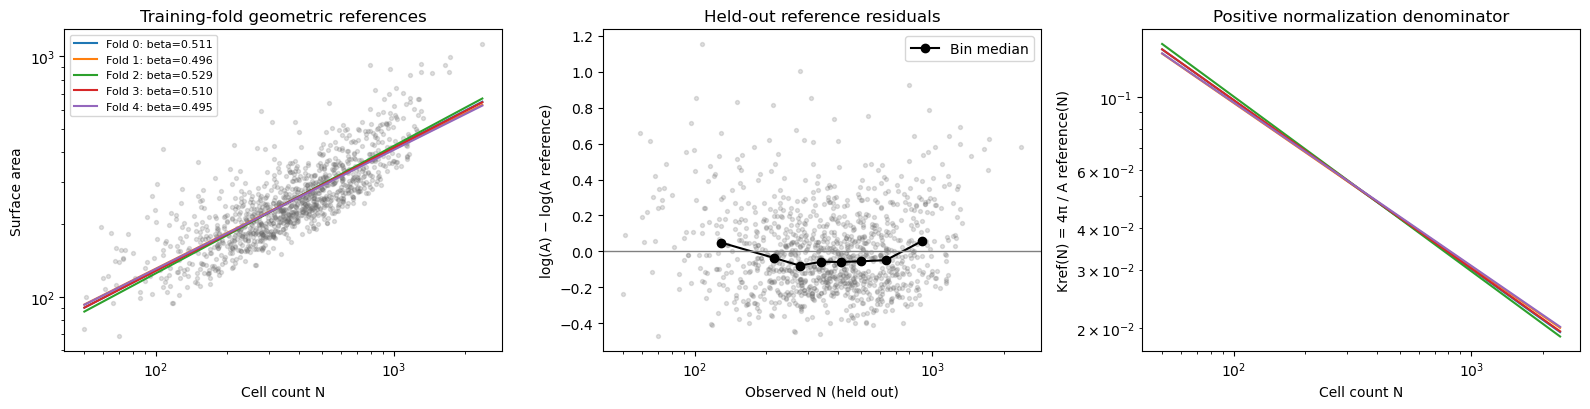

In [3]:
geom_fig, geom_axes = plt.subplots(1, 3, figsize=(16, 4.2))
geom_cohort = geom_results['cohort']
geom_n = np.geomspace(geom_cohort.n_cells.min(), geom_cohort.n_cells.max(), 150)
geom_axes[0].scatter(geom_cohort.n_cells, geom_cohort.surface_area, s=8, alpha=0.2, color='0.4')
for geom_fit in geom_results['references'].itertuples():
    geom_a = np.exp(geom_fit.alpha) * geom_n ** geom_fit.beta
    geom_axes[0].plot(geom_n, geom_a, label=f'Fold {geom_fit.fold}: beta={geom_fit.beta:.3f}')
    geom_axes[2].plot(geom_n, 4 * np.pi / geom_a)
geom_axes[0].set(xscale='log', yscale='log', xlabel='Cell count N', ylabel='Surface area', title='Training-fold geometric references')
geom_axes[0].legend(fontsize=8)
geom_val = geom_results['diagnostics'].query("role == 'val'").copy()
geom_axes[1].scatter(geom_val.n_cells, geom_val.log_area_residual, s=8, alpha=0.2, color='0.4')
geom_val['n_bin'] = pd.qcut(geom_val.n_cells, 8, duplicates='drop')
geom_residual_bins = geom_val.groupby('n_bin', observed=True).agg(n=('n_cells', 'median'), residual=('log_area_residual', 'median'))
geom_axes[1].plot(geom_residual_bins.n, geom_residual_bins.residual, 'o-', color='black', label='Bin median')
geom_axes[1].axhline(0, color='gray', lw=1)
geom_axes[1].set(xscale='log', xlabel='Observed N (held out)', ylabel='log(A) − log(A reference)', title='Held-out reference residuals')
geom_axes[1].legend()
geom_axes[2].set(xscale='log', yscale='log', xlabel='Cell count N', ylabel='Kref(N) = 4π / A reference(N)', title='Positive normalization denominator')
geom_fig.tight_layout()
geom_show_save(geom_fig, 'area_reference_diagnostics')


### Raw and normalized effects side by side

Each figure shows the same marker pair in original curvature units (left) and relative to
the geometric reference (right). Rows distinguish head-only and FiLM models. Blue circles
show observed size; orange squares show fixed-neighborhood sweeps. Axes match between models
within each column. The endpoint table reports changes between the smallest and largest
supplied N; these are descriptive differences of the plotted means, not significance tests.


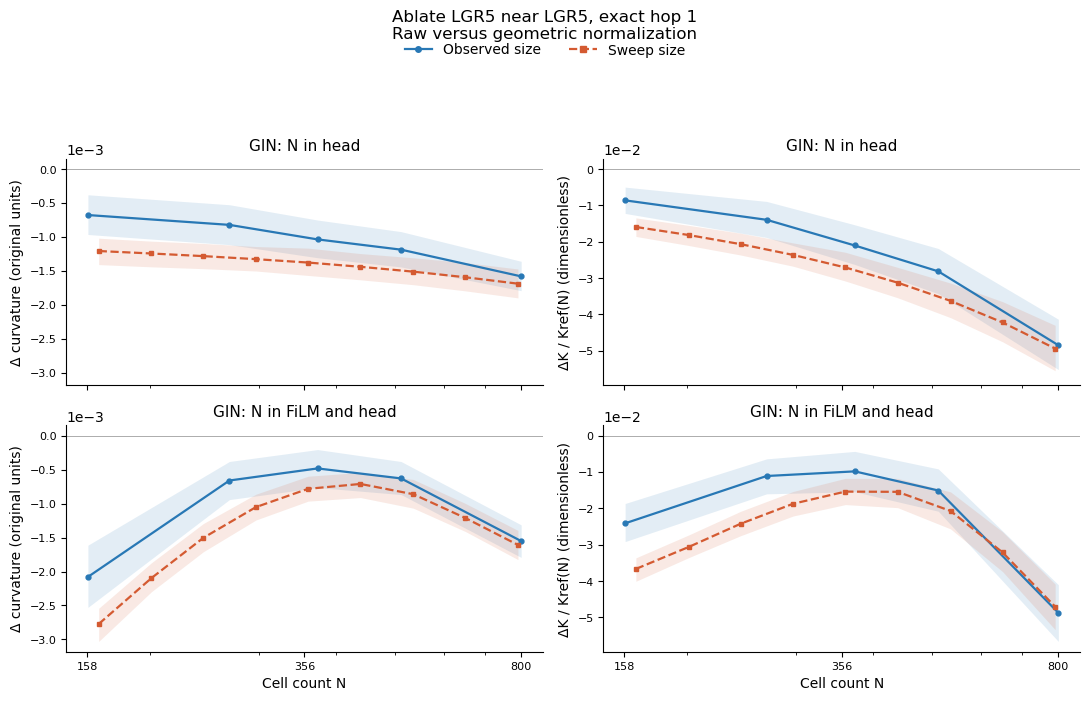

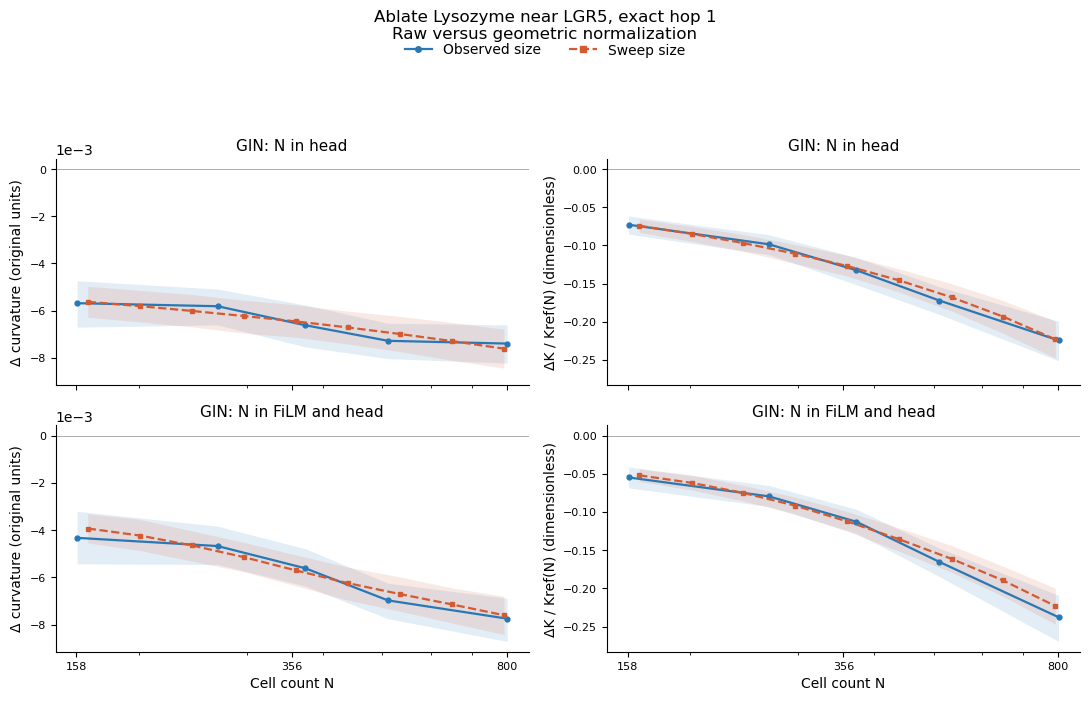

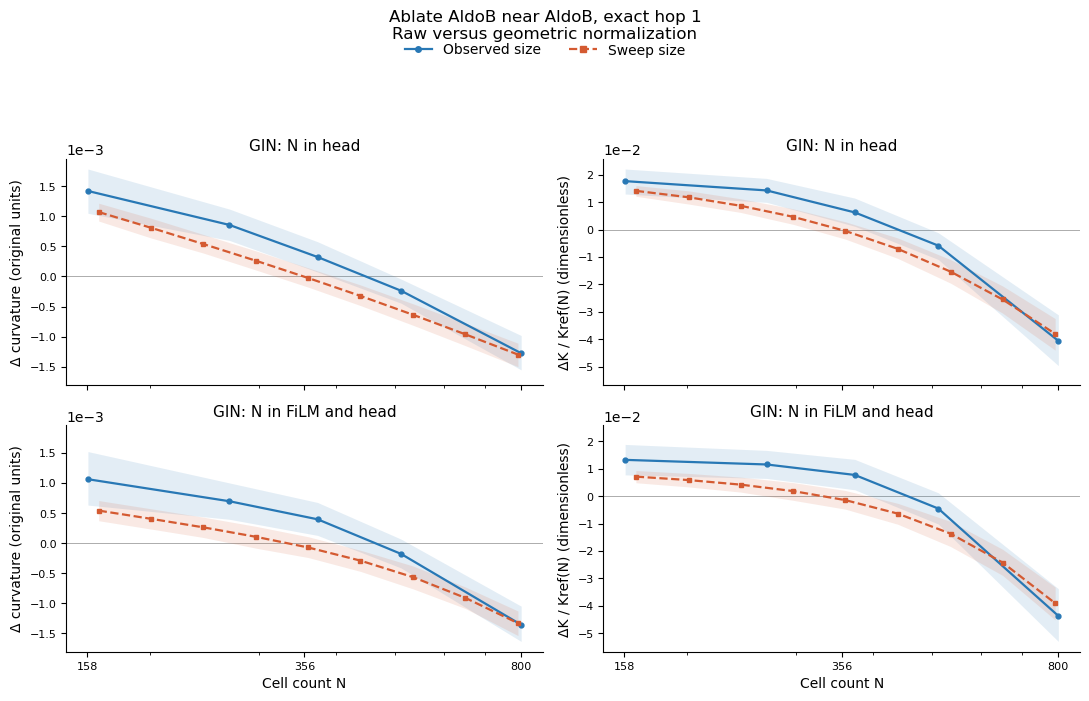

,model,center,ablated,hop,metric,n_low,n_high,low_effect,high_effect,endpoint_change,n_organoids_low,n_organoids_high
0,gin_film_size,AldoB,AldoB,1,delta_mu,165.0,791.0,0.000540,-0.001333,-0.001873,707,707
1,gin_film_size,AldoB,AldoB,1,delta_relative,165.0,791.0,0.007128,-0.039076,-0.046204,707,707
2,gin_film_size,LGR5,LGR5,1,delta_mu,165.0,791.0,-0.002773,-0.001608,0.001164,448,448
3,gin_film_size,LGR5,LGR5,1,delta_relative,165.0,791.0,-0.036678,-0.047053,-0.010376,448,448
4,gin_film_size,LGR5,Lysozyme,1,delta_mu,165.0,791.0,-0.003934,-0.007607,-0.003673,148,148
5,gin_film_size,LGR5,Lysozyme,1,delta_relative,165.0,791.0,-0.052009,-0.223096,-0.171087,148,148
6,gin_head_size,AldoB,AldoB,1,delta_mu,165.0,791.0,0.001072,-0.001300,-0.002372,707,707
7,gin_head_size,AldoB,AldoB,1,delta_relative,165.0,791.0,0.014136,-0.038053,-0.052189,707,707
8,gin_head_size,LGR5,LGR5,1,delta_mu,165.0,791.0,-0.001207,-0.001687,-0.000480,448,448
9,gin_head_size,LGR5,LGR5,1,delta_relative,165.0,791.0,-0.015941,-0.049385,-0.033444,448,448


In [4]:
for geom_pair in GEOM_FOCUS_PAIRS:
    geom_fig = plot_geometric_normalization_comparison(
        geom_summary, geom_pair, GEOM_MODELS, min_organoids=GEOM_MIN_ORGANOIDS)
    geom_show_save(geom_fig, f'{geom_pair[0]}_{geom_pair[1]}_hop{geom_pair[2]}_raw_vs_normalized')
geom_endpoint_rows = []
for (geom_model, geom_center, geom_source, geom_hop, geom_metric), geom_group in geom_summary.query("analysis == 'sweep'").groupby(
        ['model', 'center_marker', 'source_marker_name', 'hop', 'metric']):
    if (geom_center, geom_source, geom_hop) not in GEOM_FOCUS_PAIRS:
        continue
    geom_group = geom_group.sort_values('n')
    geom_low, geom_high = geom_group.iloc[0], geom_group.iloc[-1]
    geom_endpoint_rows.append(dict(model=geom_model, center=geom_center, ablated=geom_source, hop=geom_hop,
        metric=geom_metric, n_low=geom_low.n, n_high=geom_high.n,
        low_effect=geom_low['mean'], high_effect=geom_high['mean'],
        endpoint_change=geom_high['mean'] - geom_low['mean'],
        n_organoids_low=geom_low.n_organoids, n_organoids_high=geom_high.n_organoids))
geom_endpoints = pd.DataFrame(geom_endpoint_rows)
geom_endpoints.to_csv(GEOM_OUTPUT_DIR / 'selected_pair_endpoints.csv', index=False)
display(geom_endpoints)


### Normalized effects for all marker pairs

Each panel overlays observed-size and sweep-size effects, now in dimensionless units.
Y limits match between the two models for the same marker pair and hop. Points with fewer
than the configured minimum number of organoids are masked. The full raw and normalized
summaries, organoid-level means, fitted reference parameters, calibration metadata, and
PNG/PDF figures are saved in the run's `geometric_normalization` directory.


Saved post-training normalization to: /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/size_conditioned_ablation/20260910_164825_all_depth2_four_models_baseline_with_size/geometric_normalization


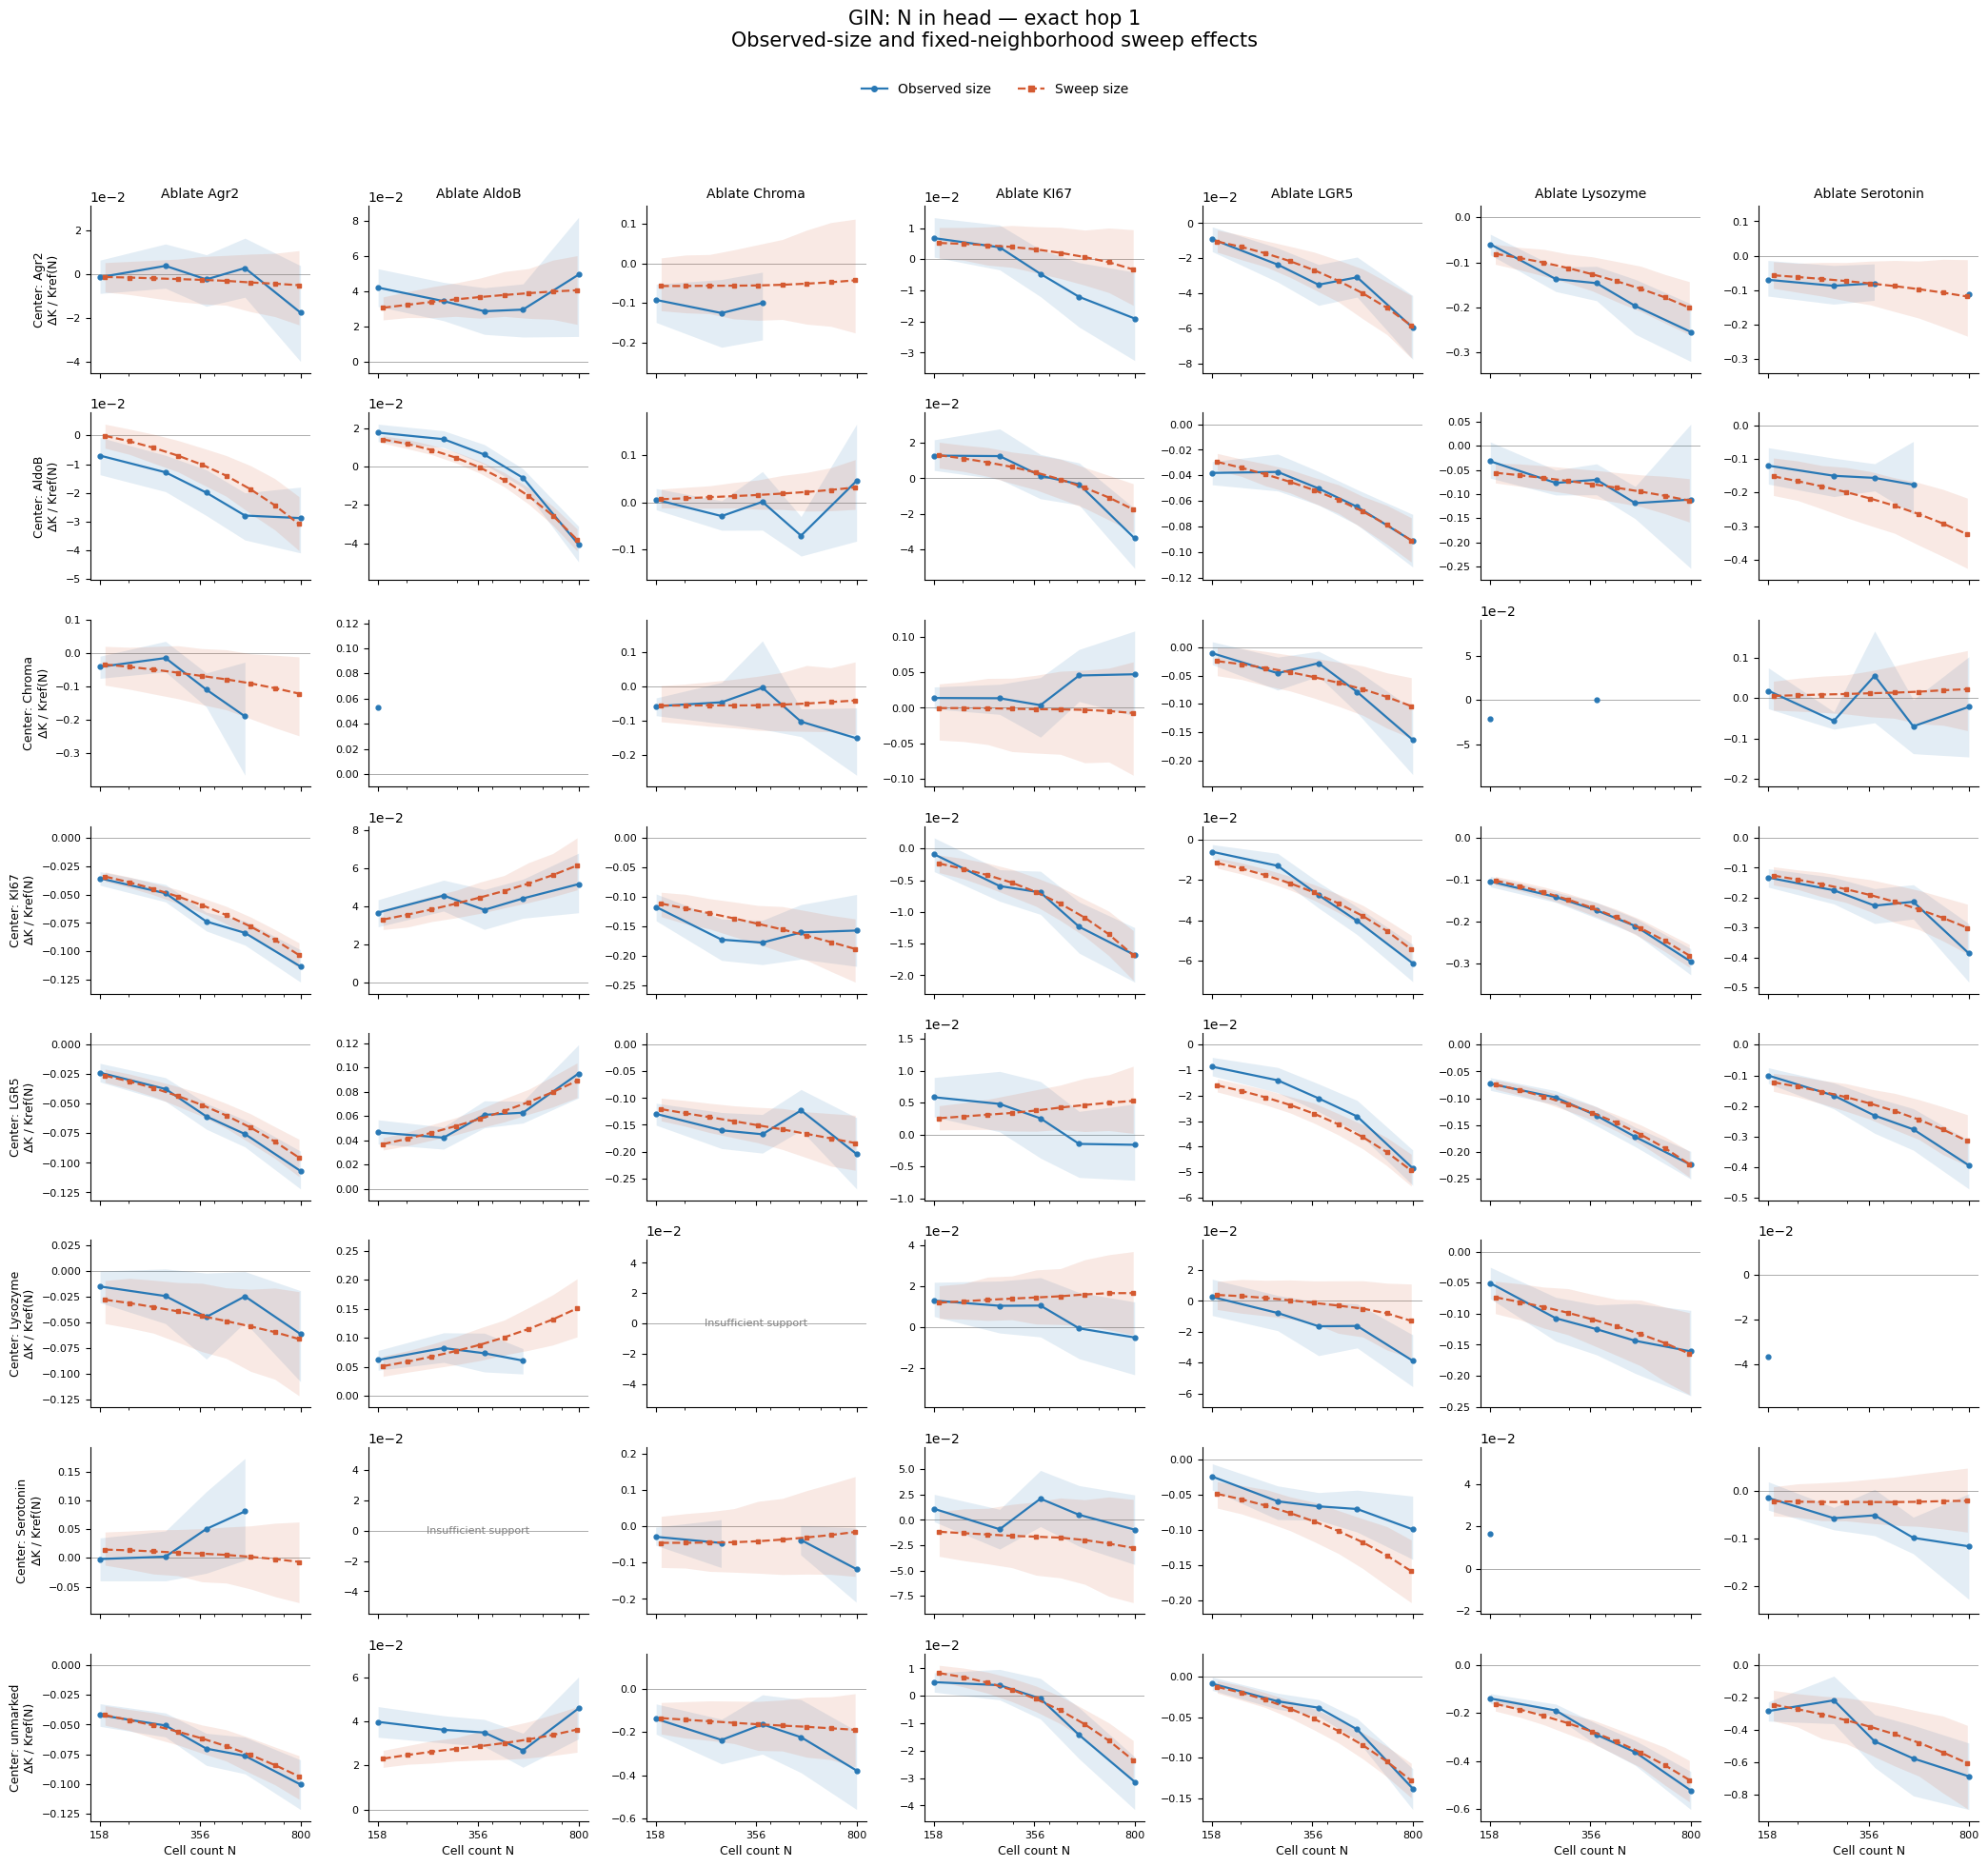

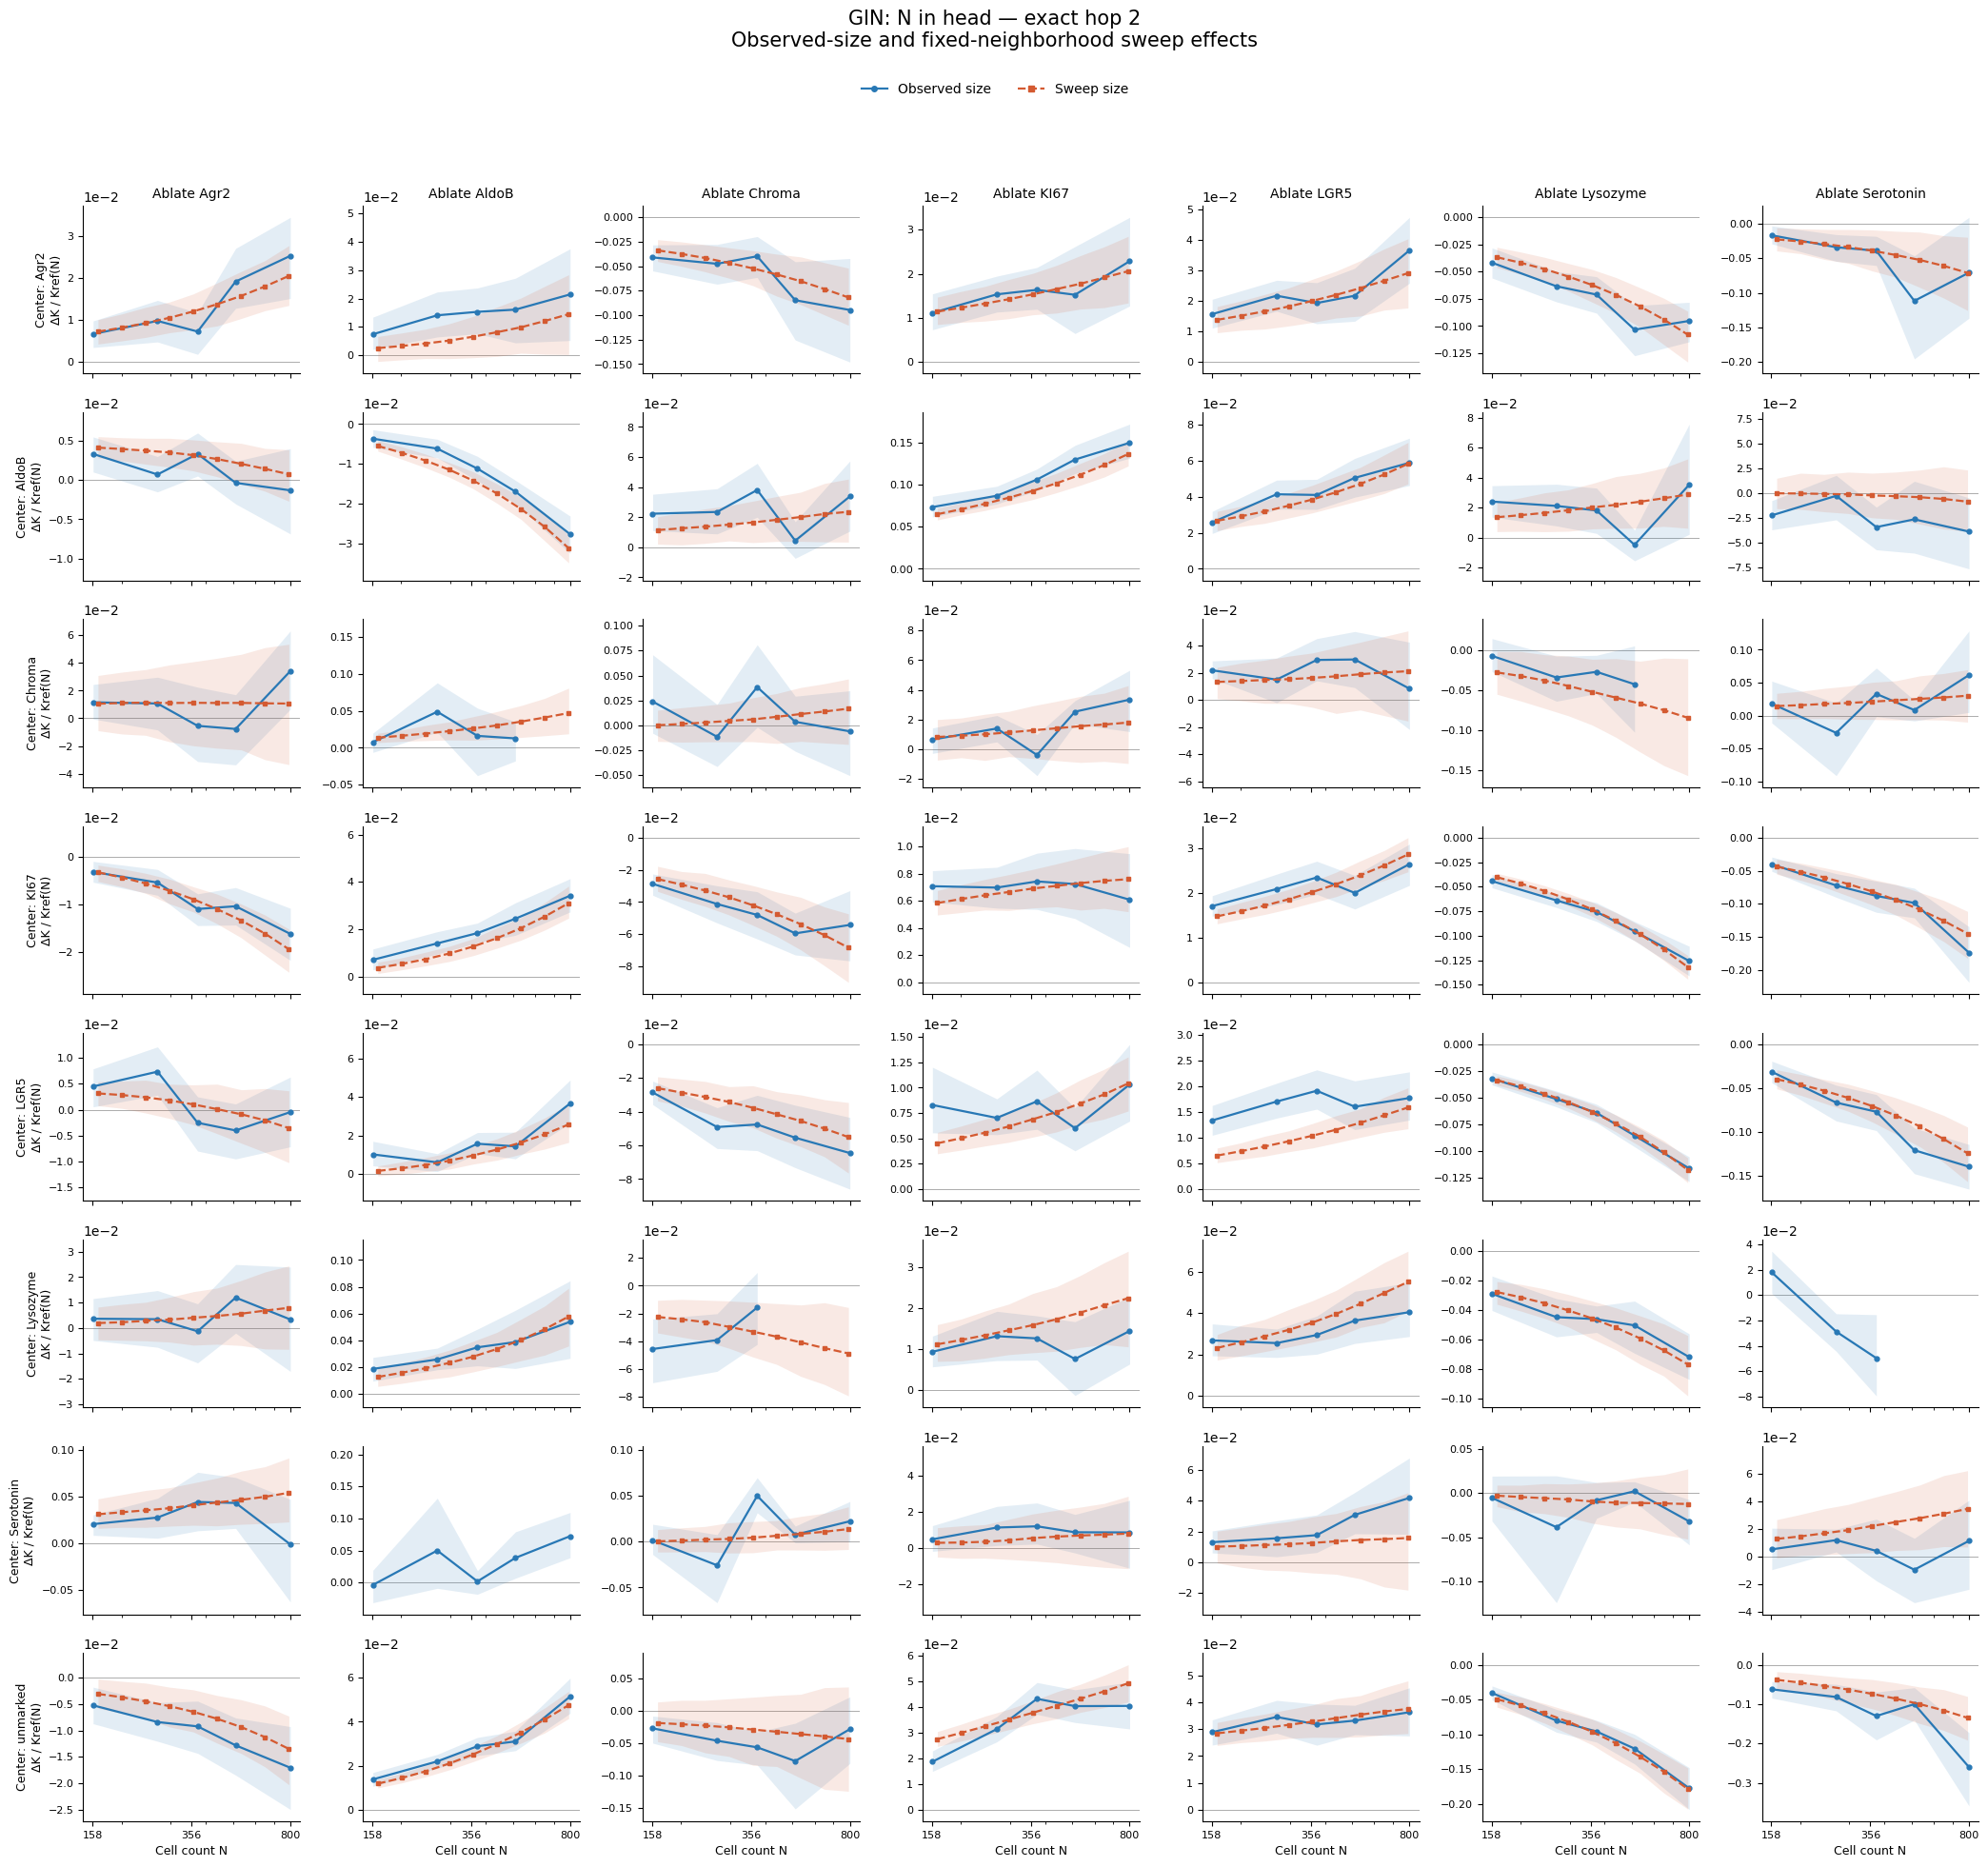

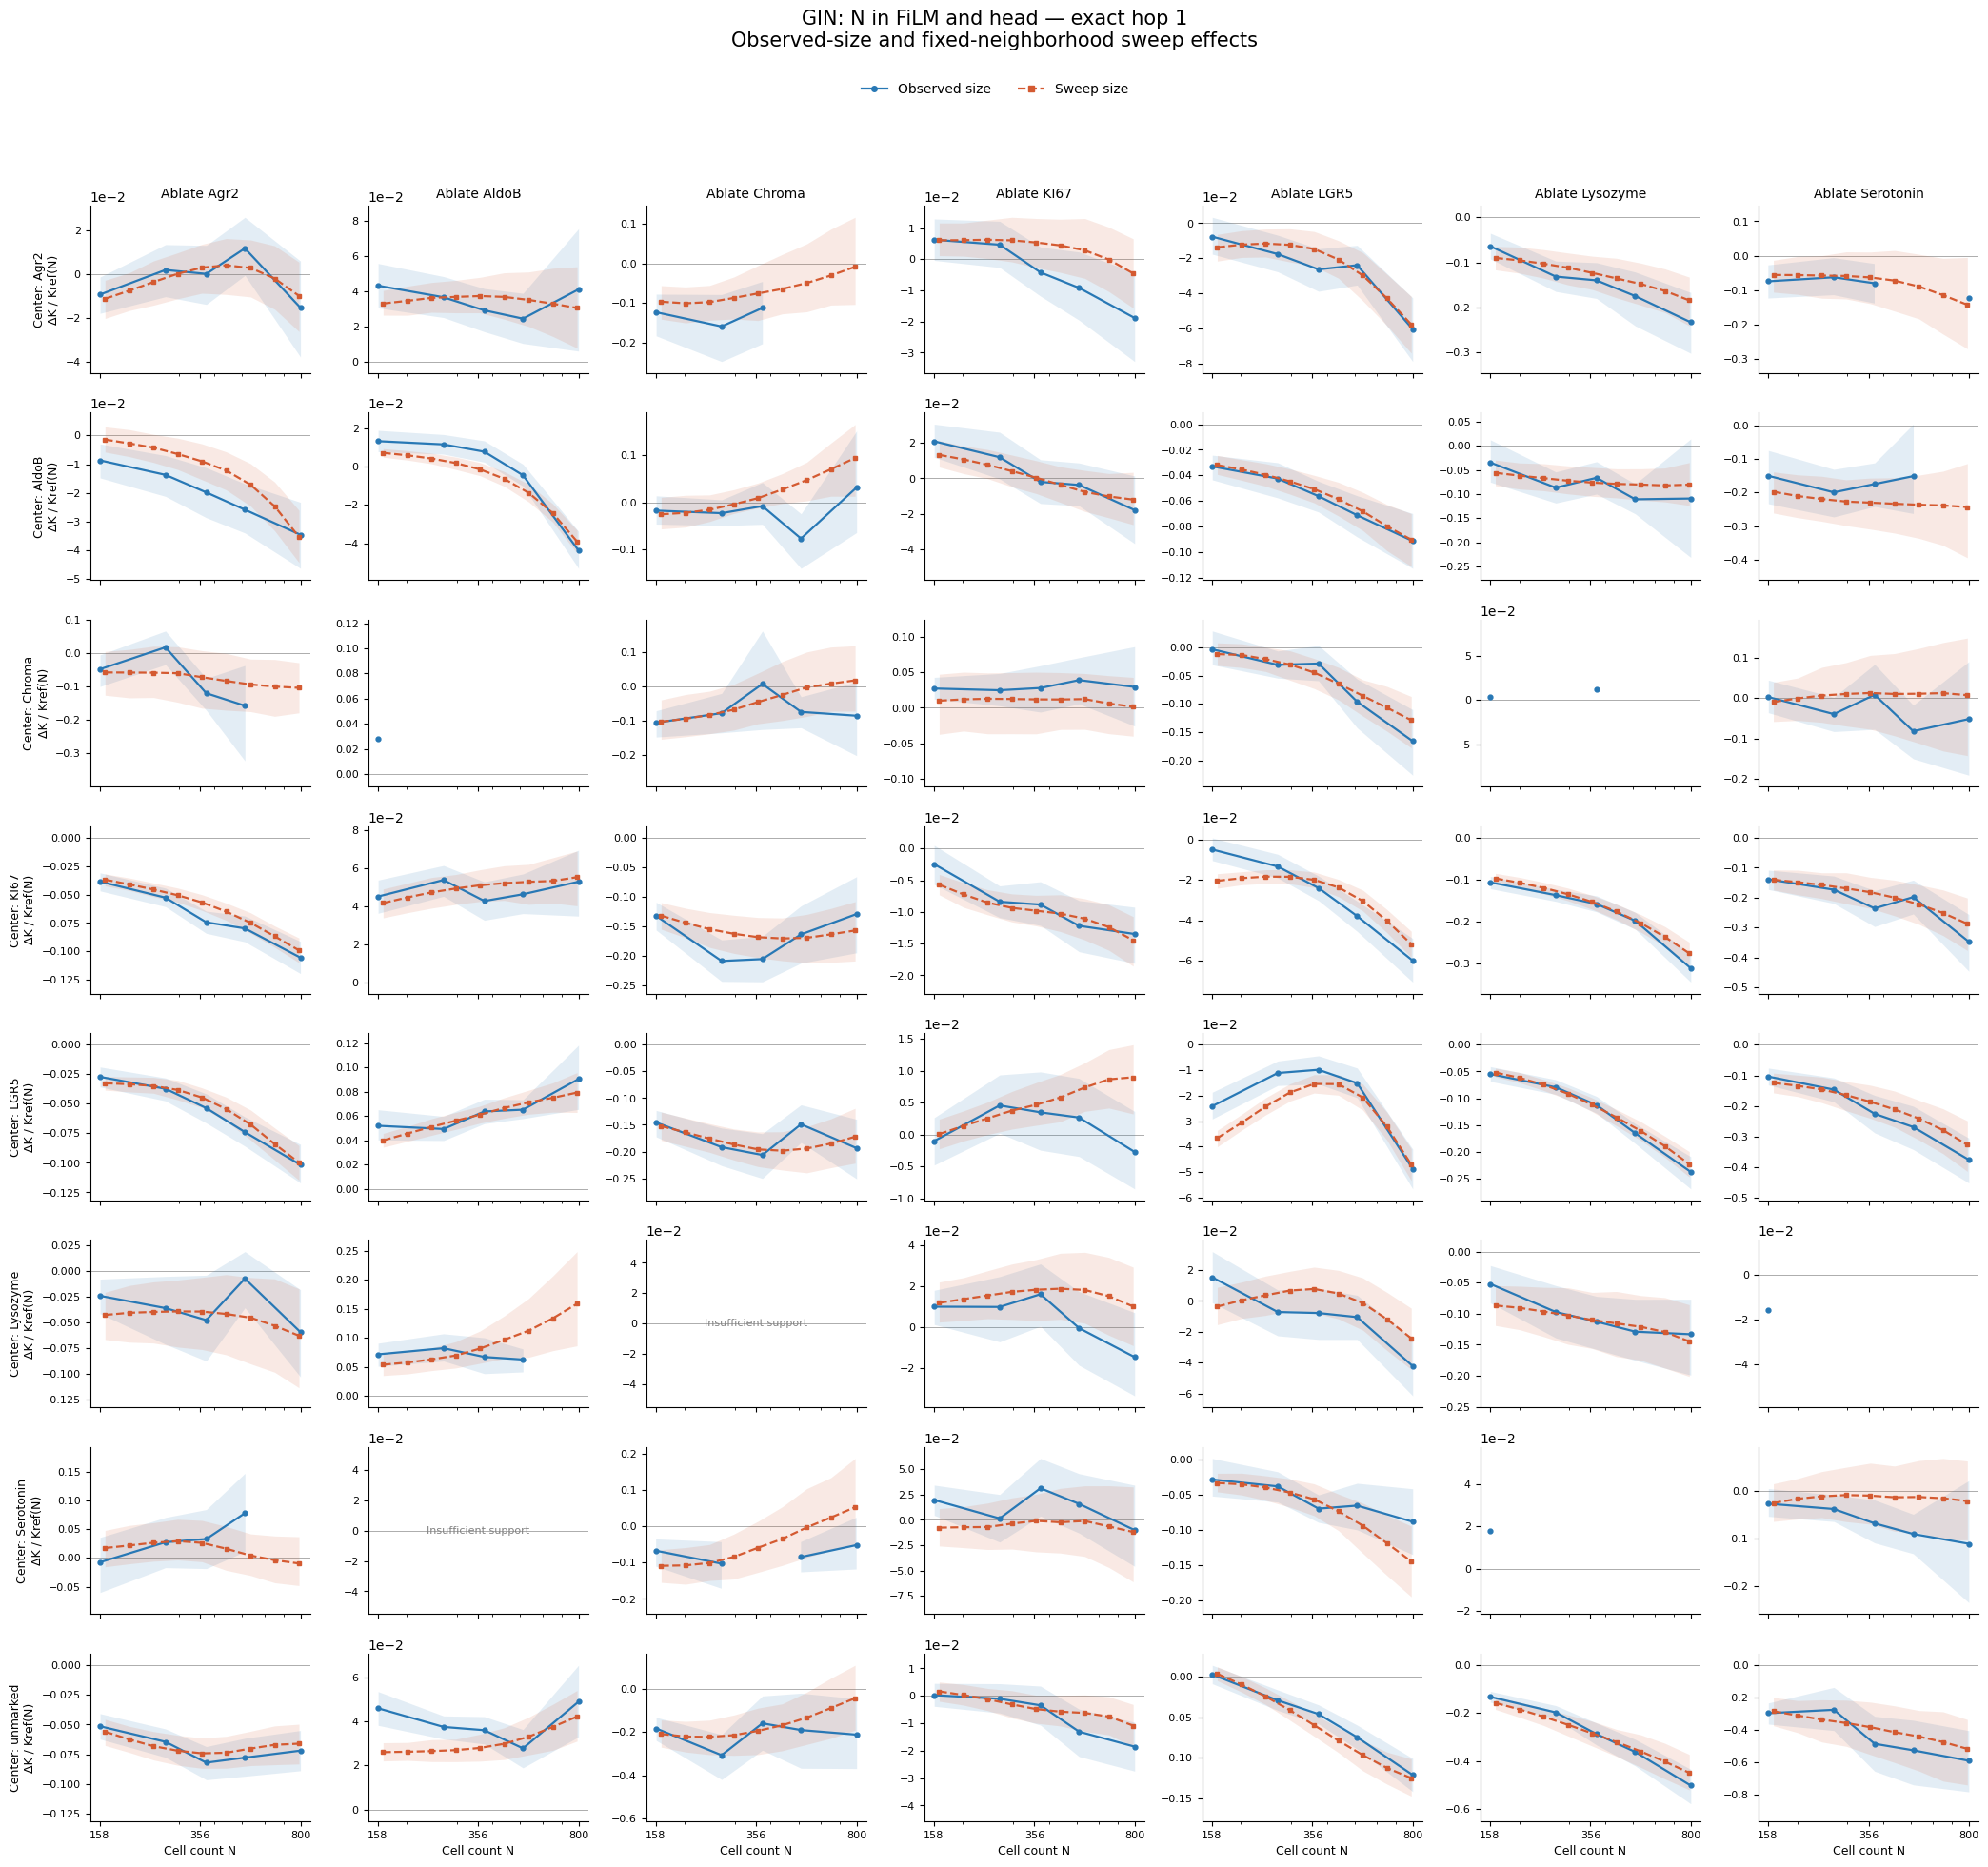

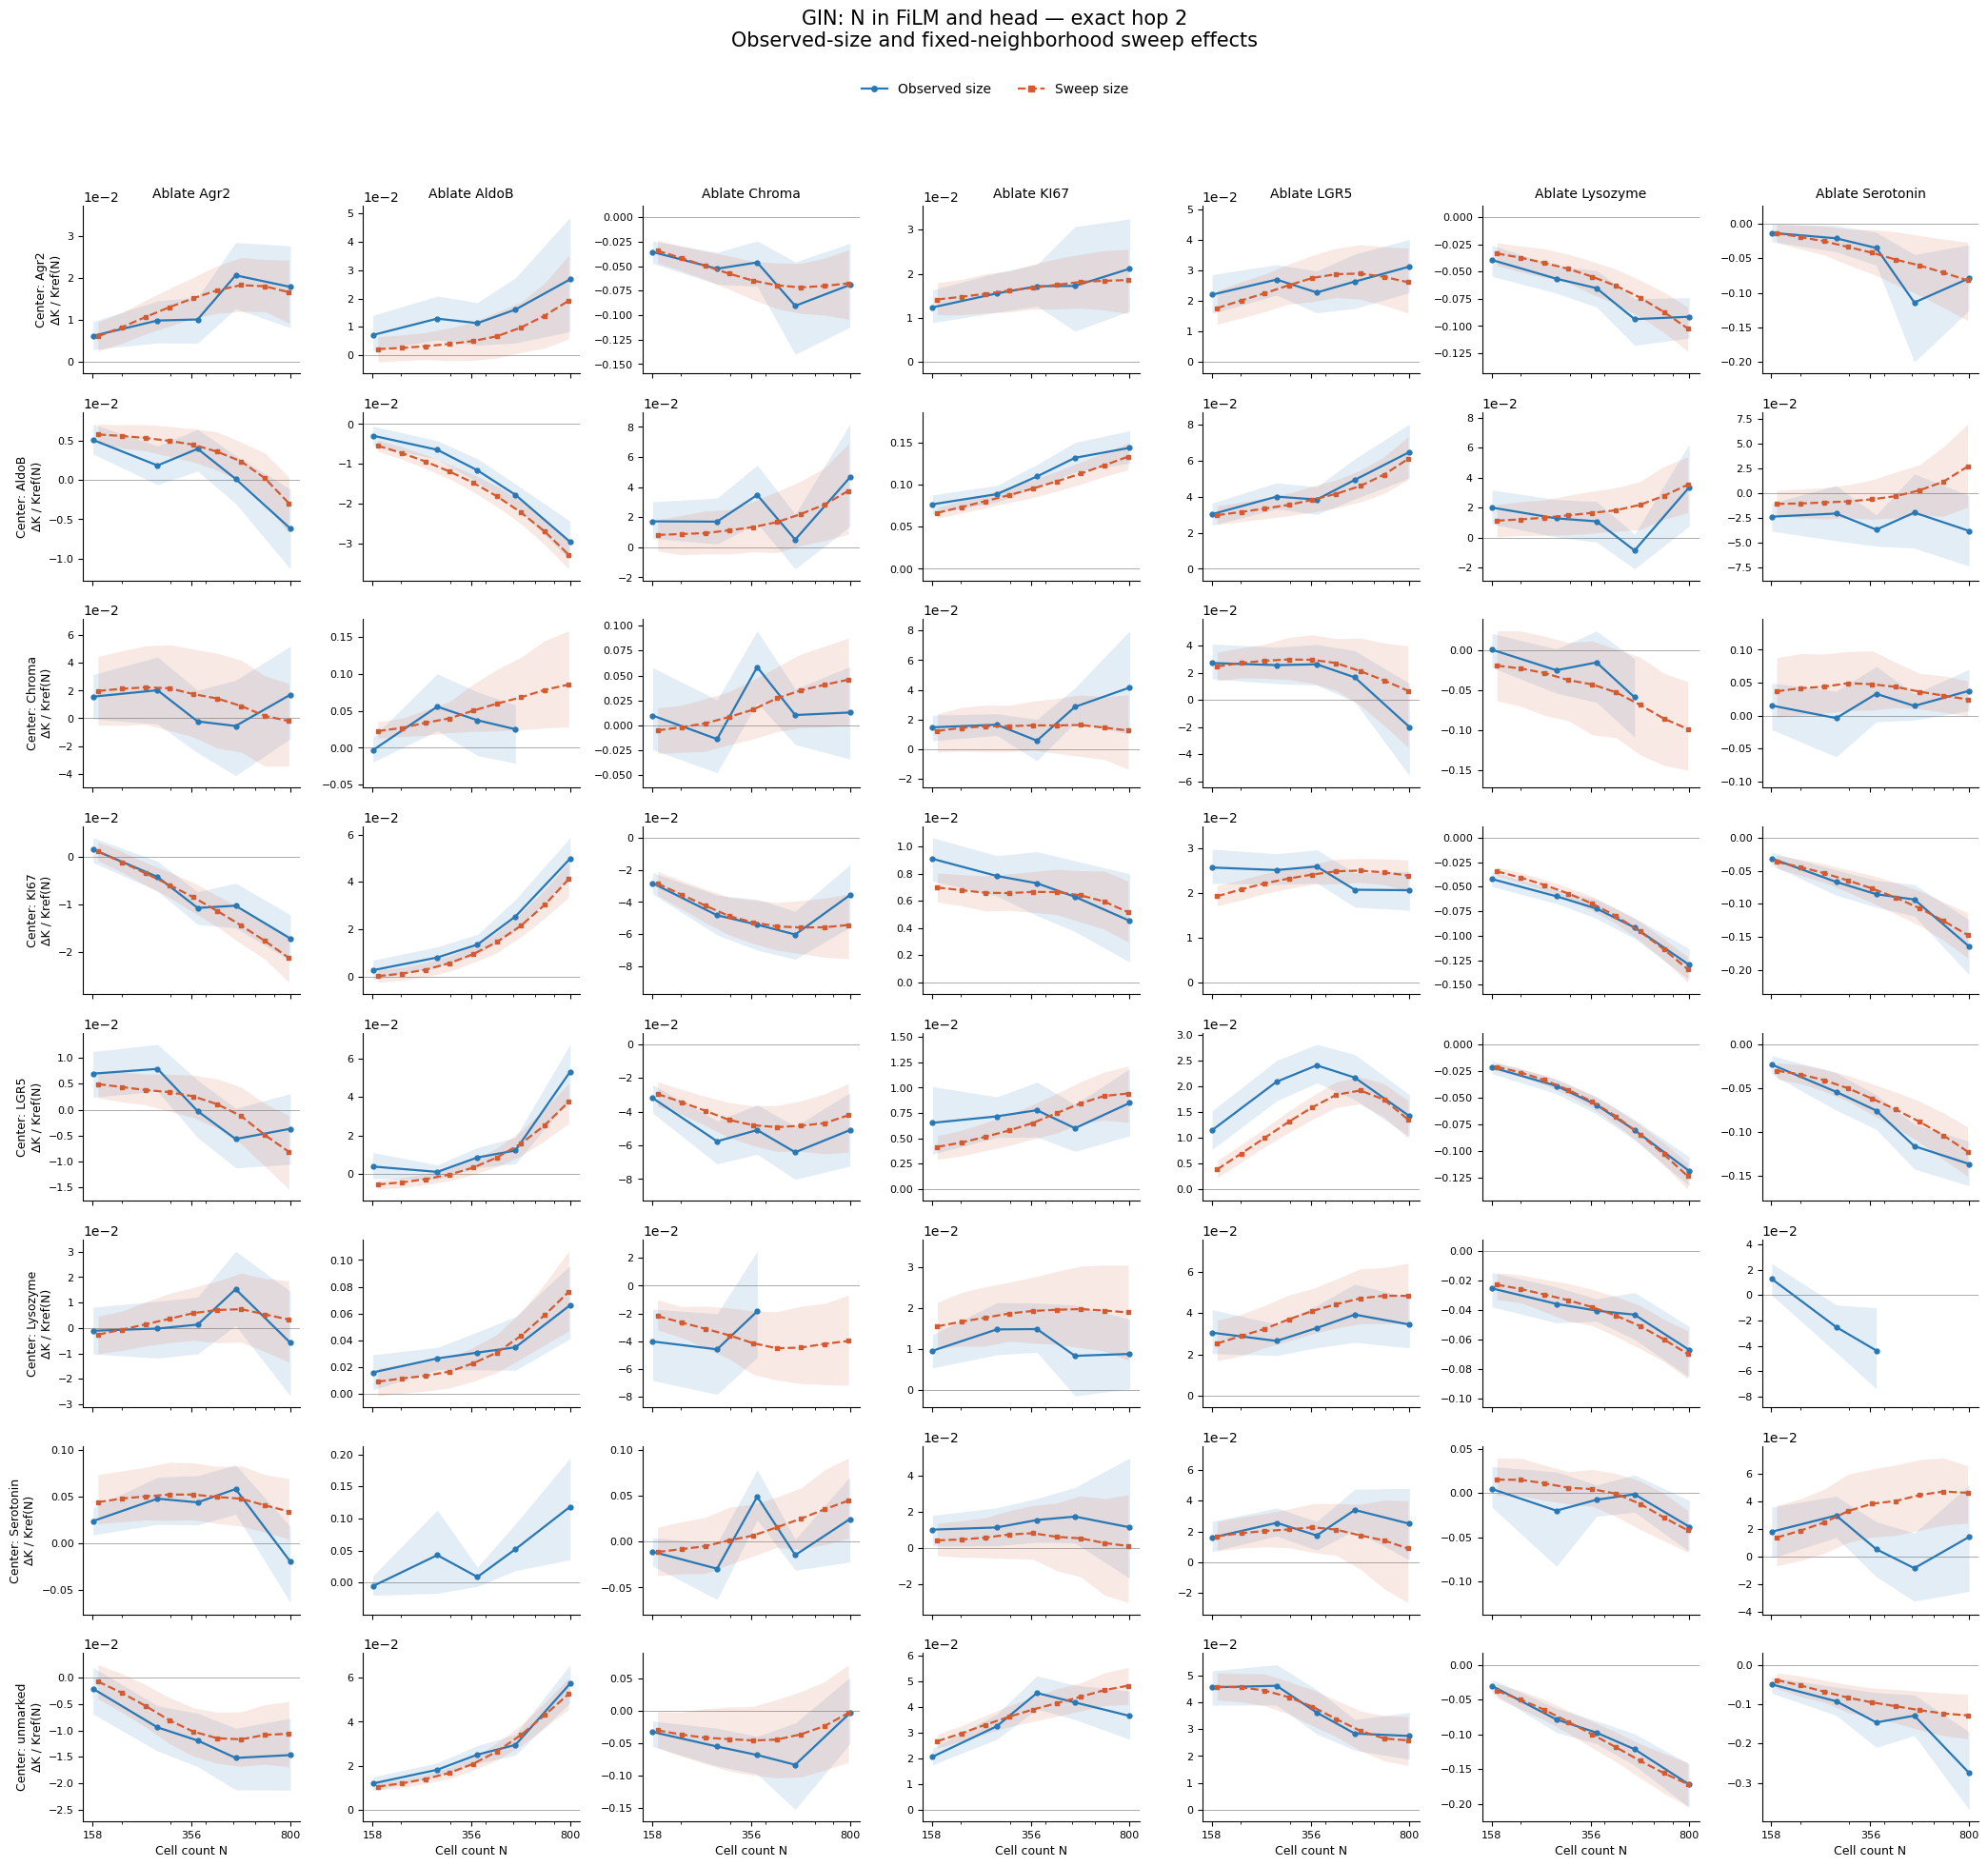

In [5]:
geom_normalized = geom_summary[geom_summary.metric == 'delta_relative'].copy()
for geom_model in GEOM_MODELS:
    for geom_hop in GEOM_HOPS:
        geom_fig = plot_size_overlay_grid(
            geom_normalized, geom_model, geom_hop, min_organoids=GEOM_MIN_ORGANOIDS,
            ylabel='ΔK / Kref(N)', match_model_limits=True,
        )
        geom_show_save(geom_fig, f'{geom_model}_hop{geom_hop}_normalized_overlays')
print('Saved post-training normalization to:', GEOM_OUTPUT_DIR)


### Reading the displayed normalization results

These outputs use 1,100 organoids from the completed filtered run. The five training-fold
area exponents range from **0.495 to 0.529**, so the reference curvature falls approximately
as N to the power −0.51. Held-out log-area R² ranges from **0.52 to 0.70**. The residual
plot shows scatter and a mild size trend: this is an empirical reference, not an exact
physical scaling law. Across the 165–791 sweep, the normalization multiplier grows by
approximately 2.2× within a fold.

For LGR5 ablation near LGR5 at hop 1, the FiLM raw endpoint effect changes from −0.00277
to −0.00161, while the dimensionless effect changes from −0.0367 to −0.0471. Its
intermediate-size turning behavior remains visible. The head-only normalized effect
changes from −0.0159 to −0.0494. Thus conclusions about endpoint magnitude depend on
whether effects are measured in absolute curvature or relative to the size reference.

Lysozyme ablation near LGR5 becomes more negative across the sweep in both units for both
models. The AldoB–AldoB sweep crosses zero in both units. A positive normalizer preserves
the sign of every individual effect, although fold-specific scaling can reweight an
aggregated curve. These are descriptive model sensitivities, not tests of causal biology.


<a id="lgr5-film-diagnostics"></a>

## FiLM interactions around LGR5-positive centers

This section contains the completed checkpoint-based diagnostics for the **FiLM model
without geometry in the head**. It can be executed independently, starting with the imports
below. By default it reads completed diagnostics and regenerates figures. Set
`LGR5_RUN_INFERENCE=True` only to run inference again; checkpoint-level completion files
allow resuming. No model or baseline is retrained. `LGR5_RECOMPUTE_SUMMARIES=True` recomputes
summaries from saved diagnostic cases without inference.

All 767 originally LGR5-positive centers in the saved size-sweep manifests are retained:
461 held-out organoids, five folds, three seeds, and N = 165, 201, 244, 297, 361, 439, 535,
650, 791. The reference is **N=361**. Center coexpression is retained and reported below.
All source cells and neighborhoods stay fixed across N, seeds, and diagnostic routes.

We distinguish five routes: both FiLM and head vary; FiLM varies with head fixed; head
varies with FiLM fixed; only FiLM layer 1 varies; only FiLM layer 2 varies. All other size
inputs stay at N=361. These are internal network interventions, not simulated organoids.
Full-route predictions are checked against the saved original sweeps for every case/N/seed.

Geometric normalization uses the existing shared training-fold references. The route plots
also show transformed curvature and curvature divided by **Kref(361)**, avoiding size trends
introduced just by changing the denominator. The GNN/head split concerns the explicit size
input: the fixed head remains nonlinear in the changing GNN representation.

All intervals are **pointwise organoid-bootstrap 95% intervals conditional on fitted models
and reference curves**. Seeds are averaged within organoids, and seed-specific results are
exported separately. Endpoint contrasts are paired within case, organoid, and seed. These
are exploratory analyses without multiplicity-adjusted significance claims.


In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

LGR5_PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src').is_dir())
if str(LGR5_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(LGR5_PROJECT_ROOT))
from src.analysis.lgr5_film import run_diagnostics
from src.analysis.lgr5_film_summary import summarize_diagnostics
from src.plotting.lgr5_film import (
    route_curves, hidden_curves, scaling_heatmap, center_interaction_curves,
    neighbor_interaction_heatmap, hidden_interaction_heatmap,
)
LGR5_RUN_NAME = '20260910_164825_all_depth2_four_models_baseline_with_size'
LGR5_RUN_DIR = LGR5_PROJECT_ROOT / 'results_experiments/size_conditioned_ablation' / LGR5_RUN_NAME
LGR5_OUTPUT_DIR = LGR5_RUN_DIR / 'lgr5_film_diagnostics'
LGR5_RUN_INFERENCE = False
LGR5_RECOMPUTE_SUMMARIES = False
LGR5_DEVICE = 'cuda'
LGR5_BATCH_SIZE = 256
LGR5_MIN_ORGANOIDS = 10
LGR5_BOOTSTRAP_SAMPLES = 1000
if LGR5_RUN_INFERENCE:
    run_diagnostics(LGR5_RUN_DIR, LGR5_PROJECT_ROOT, device=LGR5_DEVICE, batch_size=LGR5_BATCH_SIZE)
if LGR5_RECOMPUTE_SUMMARIES:
    summarize_diagnostics(LGR5_OUTPUT_DIR, draws=LGR5_BOOTSTRAP_SAMPLES, seed=42)
LGR5_CONFIG = json.loads((LGR5_OUTPUT_DIR / 'settings.json').read_text())
LGR5_COUNTS = LGR5_CONFIG['counts']
LGR5_MARKERS = LGR5_CONFIG['marker_names']
lgr5_tables = {name: pd.read_csv(LGR5_OUTPUT_DIR / f'{name}.csv') for name in [
    'sampling_support', 'reproduction_checks', 'center_coexpression_support',
    'effect_summary', 'effect_seed_summary', 'effect_endpoint_summary', 'effect_endpoint_seeds',
    'interaction_summary', 'interaction_seed_summary', 'interaction_endpoint_summary', 'interaction_endpoint_seeds',
    'common_scaling', 'common_scaling_seeds', 'common_scaling_support', 'route_interaction_summary',
]}
LGR5_FIGURE_DIR = LGR5_OUTPUT_DIR / 'figures'
LGR5_FIGURE_DIR.mkdir(exist_ok=True)
def lgr5_show_save(fig, name):
    for extension in ['png', 'pdf']:
        fig.savefig(LGR5_FIGURE_DIR / f'{name}.{extension}', dpi=150, bbox_inches='tight')
    display(fig)
    plt.close(fig)
print('Source run:', LGR5_RUN_NAME)
display(lgr5_tables['sampling_support'], lgr5_tables['center_coexpression_support'])
print('Completed checkpoints:', len(lgr5_tables['reproduction_checks']))
print('Maximum difference from original saved ΔK:', lgr5_tables['reproduction_checks'].max_saved_raw_difference.max())


Source run: 20260910_164825_all_depth2_four_models_baseline_with_size
Completed checkpoints: 15
Maximum difference from original saved ΔK: 6.558267156685922e-08


,fold,centers,organoids,single_cases,neighbor_pairs,skipped_same_source_pairs
0,0,140,82,855,912,119
1,1,153,94,927,1007,121
2,2,140,86,871,952,108
3,3,162,94,994,1085,144
4,4,172,105,1098,1248,166


,center_markers,n_centers,n_organoids
0,AldoB|KI67|LGR5,31,28
1,AldoB|LGR5,38,34
2,KI67|LGR5,405,287
3,LGR5,293,211


### 1. Changes in marker preference beyond common scaling

For each pair of neighboring markers and hop, retain only centers where both selected
source-positive cells exist. This common-support cohort is fixed across N and seeds.
Pairs may involve two markers on the same source cell in this sensitivity comparison;
the neighbor–neighbor factorial experiment below instead requires distinct cells.
A joint seven-marker cohort would be restrictive; the matched-pair analysis makes support
explicit and avoids averaging different marker-specific cohorts as though they were matched.

Fit the best nonnegative multiplier $a(N)$ of the two-marker mean response at N=361.
The heatmap shows $\|e(N)-a(N)e(361)\|/\|e(N)\|$: 0 means a common positive scale fits;
1 means it explains none of the response vector's norm. This is a **norm fraction, not a
fraction of variance**. Pair-specific marker residuals, gains, bootstrap intervals, and
seed results are exported. Near-zero vectors are undefined. The bootstrap refits the
multiplier using whole paired organoid curves; positive mismatch intervals alone are not
a calibrated test against zero. Both geometric and transformed scales are shown.


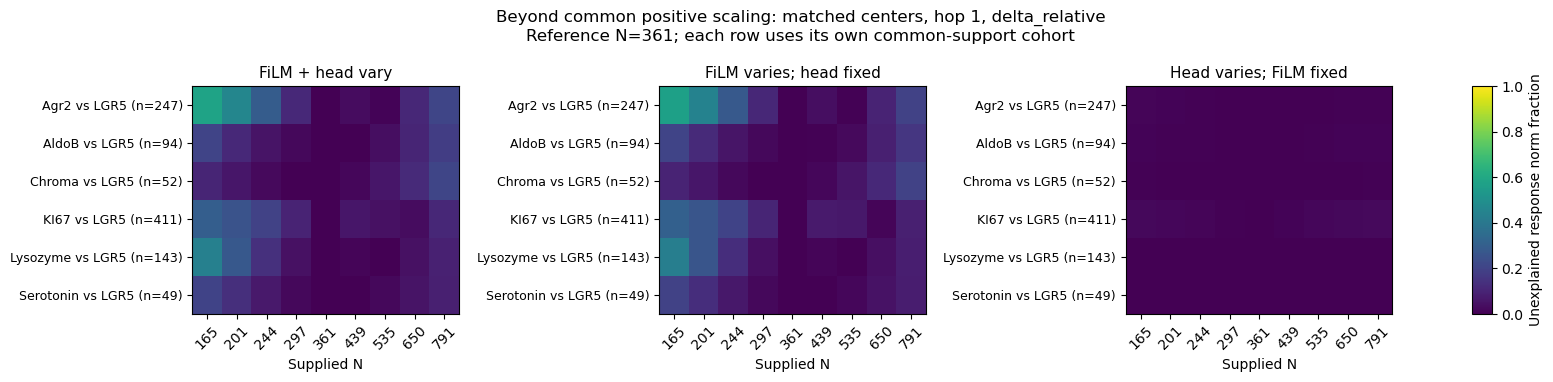

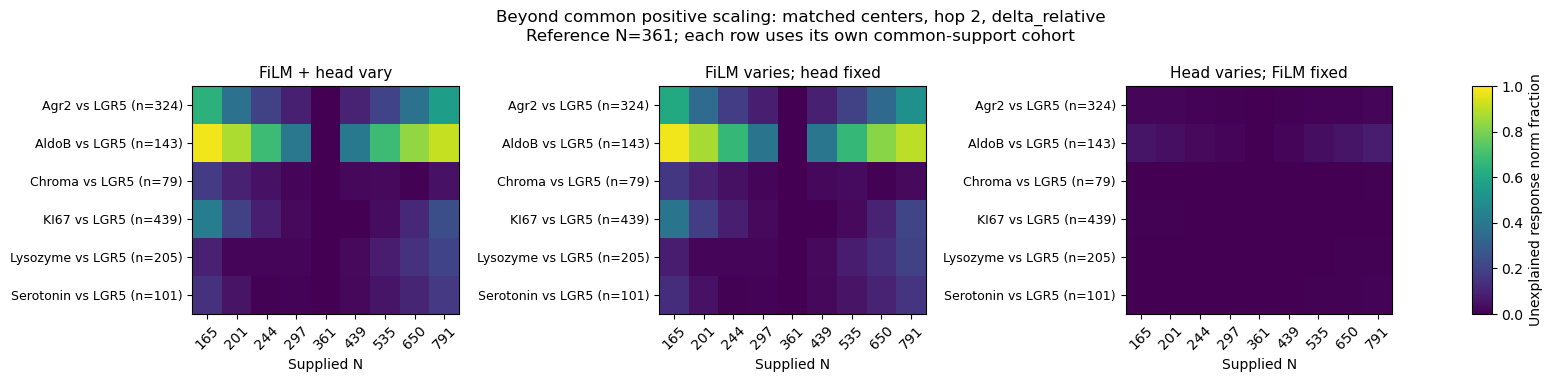

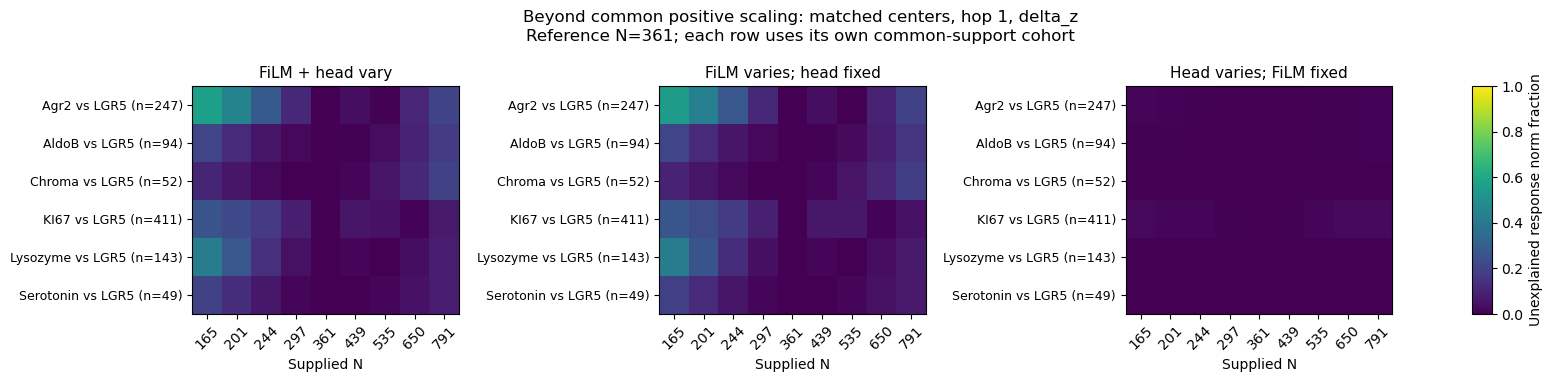

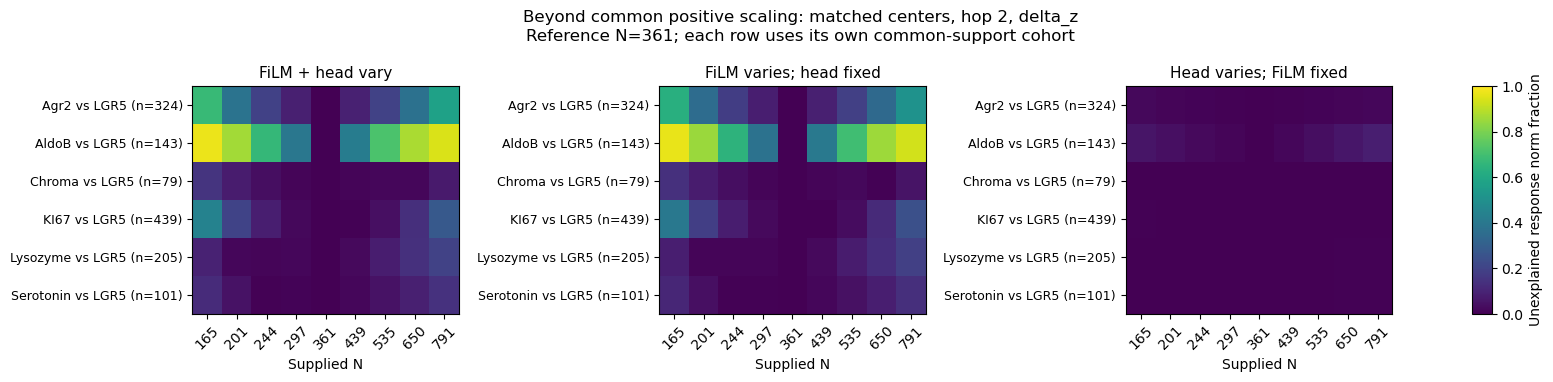

,route,hop,metric,marker_a,marker_b,n,n_organoids,n_centers,gain,gain_low,gain_high,deviation_a,deviation_a_low,deviation_a_high,deviation_b,deviation_b_low,deviation_b_high,mismatch,mismatch_low,mismatch_high
315,full,1,delta_z,LGR5,Lysozyme,165,143,166,0.731173,0.658282,0.804060,-0.343913,-0.430787,-0.273539,0.003365,-0.017612,0.027479,0.425643,0.339809,0.527239
1035,film_only,1,delta_z,LGR5,Lysozyme,165,143,166,0.707628,0.638732,0.769146,-0.326490,-0.407279,-0.258203,0.003195,-0.015740,0.024082,0.418960,0.326715,0.522290
1755,head_only,1,delta_z,LGR5,Lysozyme,165,143,166,1.014431,1.009694,1.018985,-0.002044,-0.005368,0.001168,0.000020,-0.000177,0.000178,0.002015,0.000105,0.005295


,route,hop,metric,marker_a,marker_b,seed,n,gain,deviation_a,deviation_b,mismatch
945,full,1,delta_z,LGR5,Lysozyme,42,165,0.743095,-0.309854,0.015010,0.385244
954,full,1,delta_z,LGR5,Lysozyme,43,165,0.761464,-0.312431,-0.001200,0.379595
963,full,1,delta_z,LGR5,Lysozyme,44,165,0.682711,-0.411458,-0.004794,0.516210
3105,film_only,1,delta_z,LGR5,Lysozyme,42,165,0.715330,-0.298665,0.014468,0.385672
3114,film_only,1,delta_z,LGR5,Lysozyme,43,165,0.723880,-0.299272,-0.001150,0.382066
3123,film_only,1,delta_z,LGR5,Lysozyme,44,165,0.679741,-0.383537,-0.004469,0.491437
5265,head_only,1,delta_z,LGR5,Lysozyme,42,165,1.013834,-0.003170,0.000154,0.003130
5274,head_only,1,delta_z,LGR5,Lysozyme,43,165,1.024948,0.005367,0.000021,0.005237
5283,head_only,1,delta_z,LGR5,Lysozyme,44,165,1.002918,-0.009417,-0.000110,0.009390


In [2]:
for lgr5_metric in ['delta_relative', 'delta_z']:
    for lgr5_hop in [1, 2]:
        lgr5_show_save(scaling_heatmap(lgr5_tables['common_scaling'], LGR5_COUNTS,
            hop=lgr5_hop, metric=lgr5_metric), f'common_scaling_{lgr5_metric}_hop{lgr5_hop}')
display(lgr5_tables['common_scaling'].query(
    "marker_a == 'LGR5' and marker_b == 'Lysozyme' and hop == 1 and metric == 'delta_z' and n == 165"))
display(lgr5_tables['common_scaling_seeds'].query(
    "marker_a == 'LGR5' and marker_b == 'Lysozyme' and hop == 1 and metric == 'delta_z' and n == 165"))


### 2. Separate GNN conditioning from the explicit head size input

The first two figures use transformed curvature and a **fixed** geometric denominator
Kref(361). A varying Kref(N) is deliberately avoided for route attribution. The third figure
isolates the two FiLM layers. These routes need not add up to the full response: the
network is nonlinear. The exported `route_interaction_summary.csv` also measures
`full − FiLM-only − head-only + reference` in transformed curvature at each N.

Each marker panel uses its original source-positive cohort, held fixed across all routes
and sizes. Panels with fewer than ten organoids are masked. The common-scaling analysis
above provides the stricter matched-center comparisons between different markers.


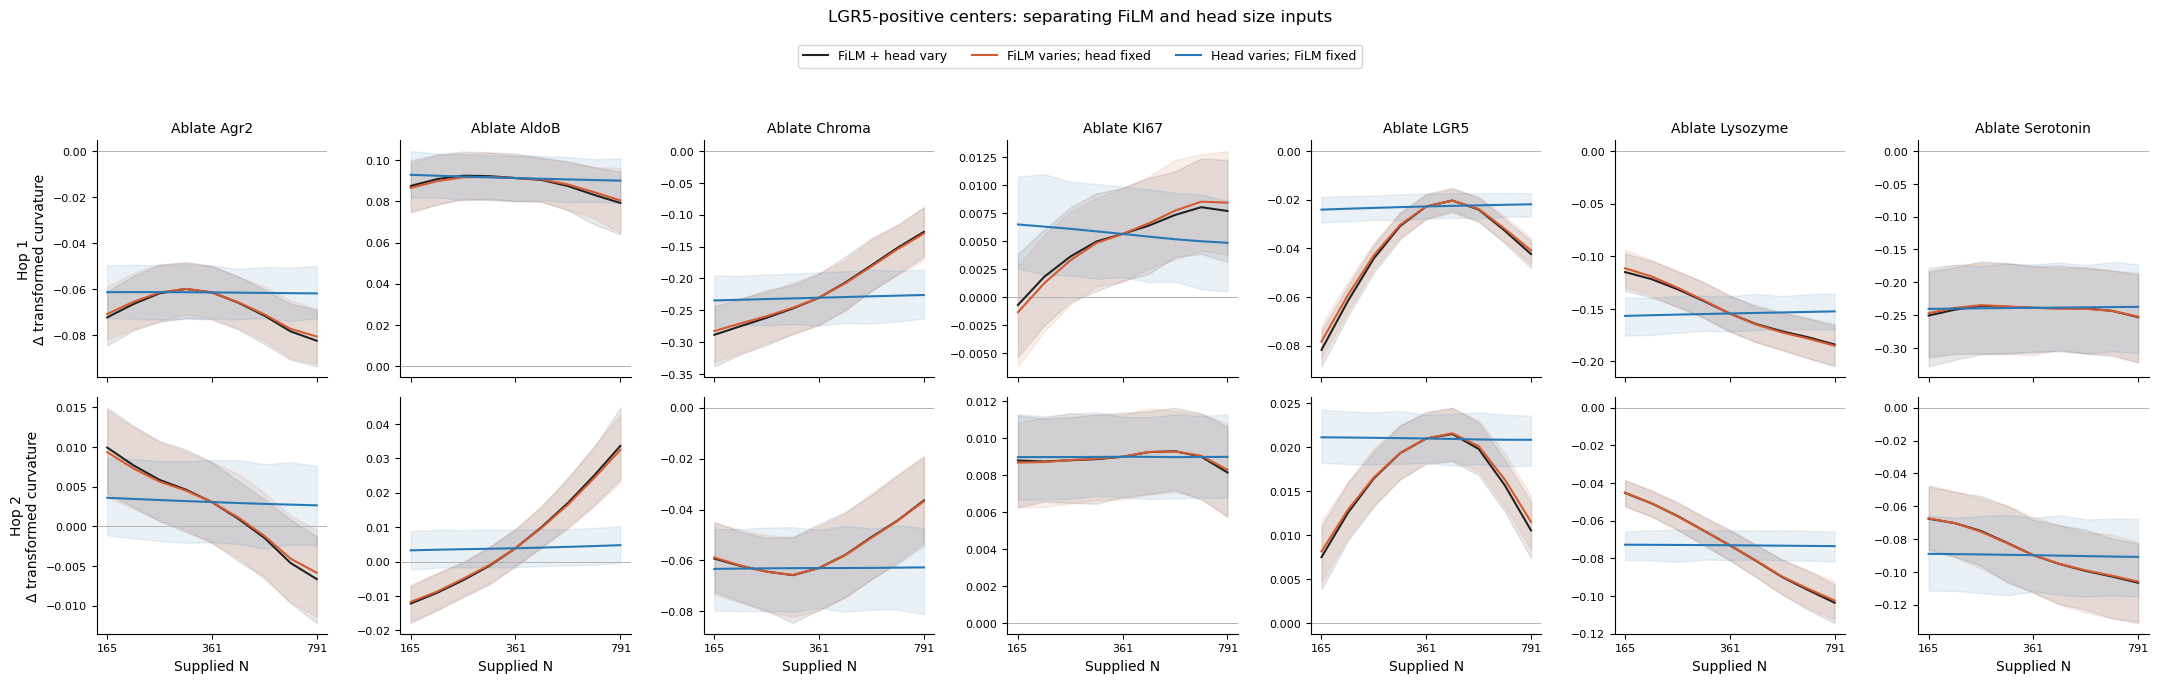

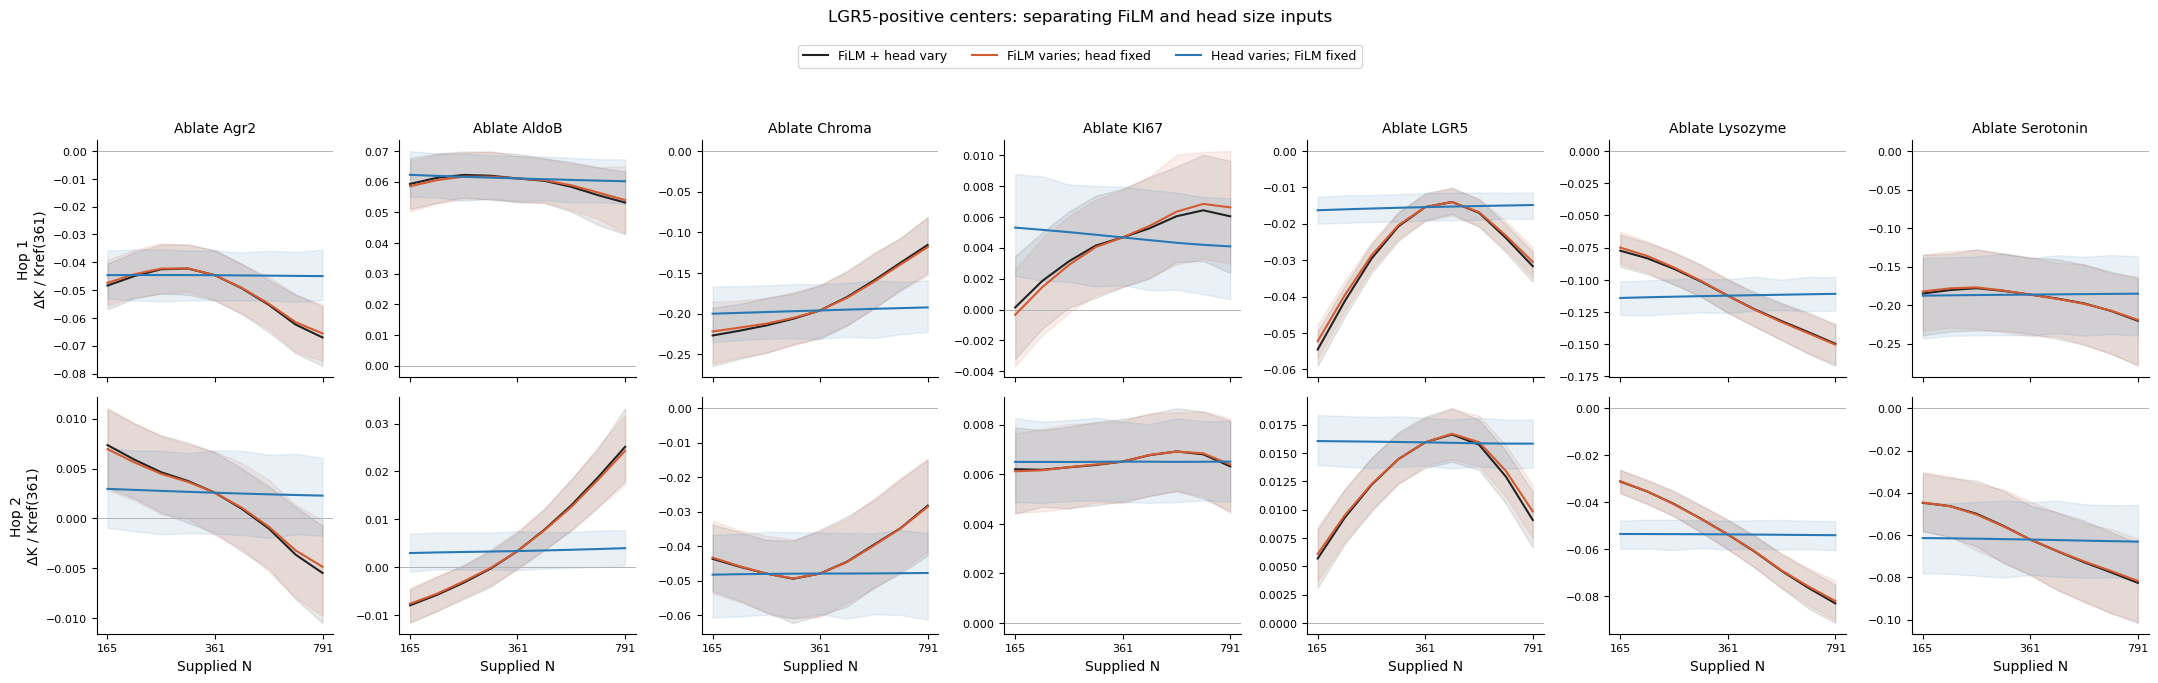

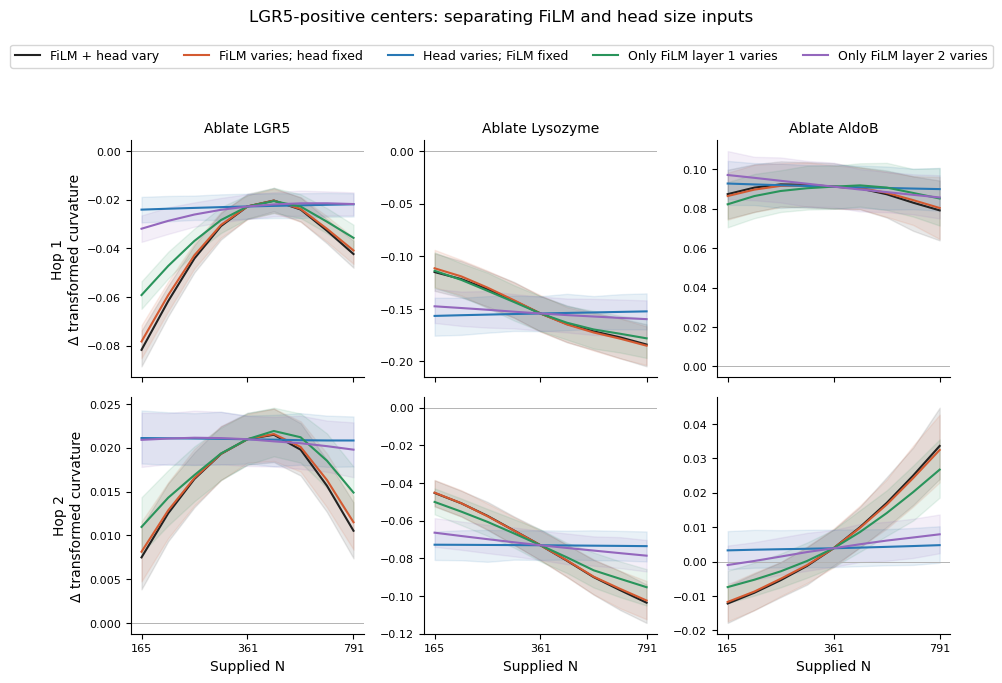

,route,source_marker_name,hop,metric,mean,ci_low,ci_high,n_organoids
8,film_only,AldoB,1,delta_z,-0.006076,-0.020252,0.010101,102
32,film_only,LGR5,1,delta_z,0.037397,0.032143,0.042773,448
40,film_only,Lysozyme,1,delta_z,-0.073602,-0.090534,-0.055885,148
64,full,AldoB,1,delta_z,-0.008240,-0.025011,0.008383,102
88,full,LGR5,1,delta_z,0.039358,0.033912,0.044577,448
96,full,Lysozyme,1,delta_z,-0.068876,-0.087104,-0.050917,148
120,head_only,AldoB,1,delta_z,-0.002829,-0.004140,-0.001501,102
144,head_only,LGR5,1,delta_z,0.002198,0.001655,0.002793,448
152,head_only,Lysozyme,1,delta_z,0.004323,0.003106,0.005564,148
176,layer1_only,AldoB,1,delta_z,0.002944,-0.008924,0.016136,102


,seed,route,source_marker_name,hop,delta_z,delta_raw,delta_relative,delta_fixed_reference
8,42,film_only,LGR5,1,0.027863,0.000750,-0.021240,0.014755
10,42,film_only,Lysozyme,1,-0.072486,-0.003693,-0.164484,-0.072649
22,42,full,LGR5,1,0.028198,0.000730,-0.022909,0.014371
24,42,full,Lysozyme,1,-0.066425,-0.003525,-0.161485,-0.069342
36,42,head_only,LGR5,1,0.000697,0.000015,-0.017548,0.000302
38,42,head_only,Lysozyme,1,0.003547,0.000096,-0.082925,0.001883
50,42,layer1_only,LGR5,1,0.013275,0.000312,-0.025218,0.006142
52,42,layer1_only,Lysozyme,1,-0.064987,-0.003185,-0.151620,-0.062648
64,42,layer2_only,LGR5,1,0.013230,0.000438,-0.010875,0.008618
66,42,layer2_only,Lysozyme,1,-0.013857,-0.000710,-0.098897,-0.013960


In [3]:
for lgr5_metric in ['delta_z', 'delta_fixed_reference']:
    lgr5_show_save(route_curves(lgr5_tables['effect_summary'], LGR5_MARKERS, LGR5_COUNTS,
        metric=lgr5_metric, minimum=LGR5_MIN_ORGANOIDS), f'route_comparison_{lgr5_metric}')
lgr5_show_save(route_curves(lgr5_tables['effect_summary'], ['LGR5','Lysozyme','AldoB'], LGR5_COUNTS,
    routes=['full','film_only','head_only','layer1_only','layer2_only'], minimum=LGR5_MIN_ORGANOIDS),
    'layer_specific_size_routes')
display(lgr5_tables['effect_endpoint_summary'].query(
    "metric == 'delta_z' and hop == 1 and source_marker_name in ['LGR5','Lysozyme','AldoB']"))
display(lgr5_tables['effect_endpoint_seeds'].query(
    "hop == 1 and source_marker_name in ['LGR5','Lysozyme']"))


### 3. Direction and magnitude of hidden marker responses

For each individual ablation, compute the change in the center representation after each
GNN layer, including ReLU and residual connections, but **before appending global features
to the head**. Compare its direction (cosine similarity) and norm with the same case and
checkpoint at N=361, then average within organoids. Cosine 1 means the same direction;
lower values mean a different combination of hidden features responds to that marker.

A zero response has no defined direction, and is excluded from cosine/ratio summaries.
Hop-2 perturbations cannot reach the center in layer 1, so that combination is omitted.
Hidden coordinates and norms are model-specific: no channel alignment across seeds is
assumed. These measurements support a representation-level change, not a biological
interpretation of individual FiLM channels. Changes in direction can arise from
size-dependent channel scaling as well as nonlinear feature computation.


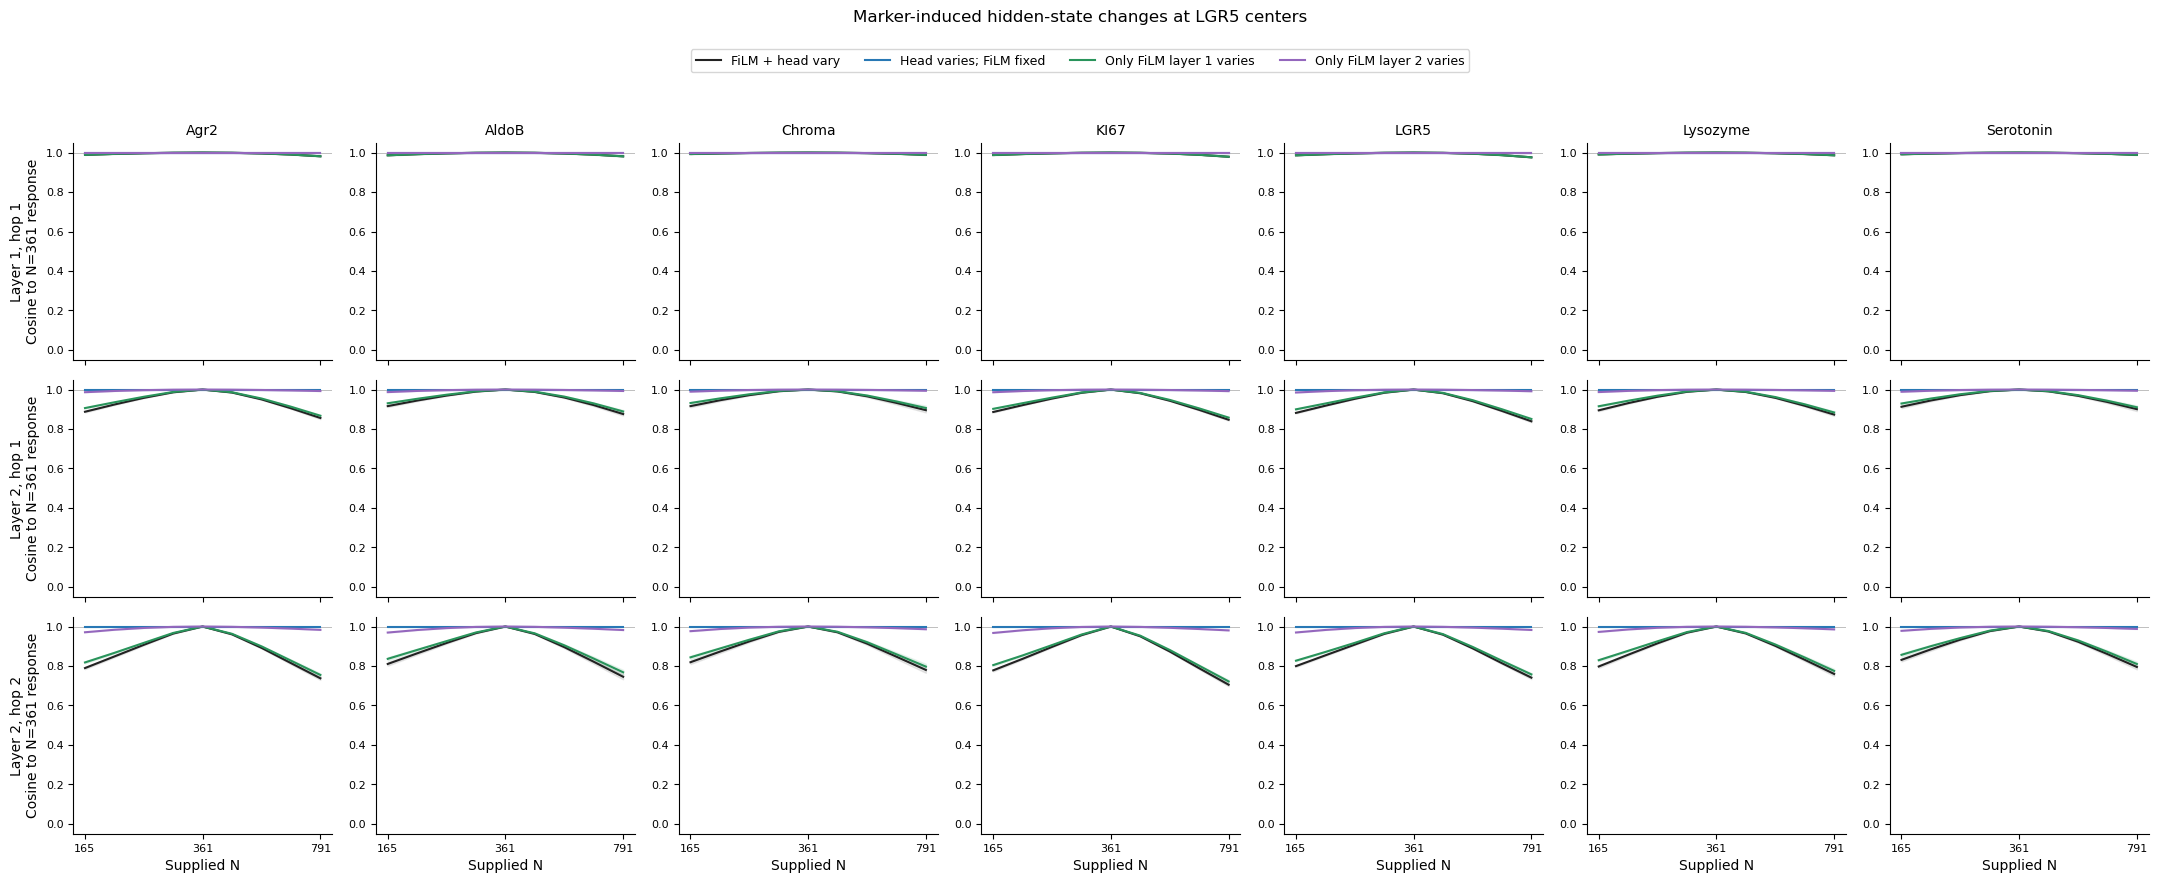

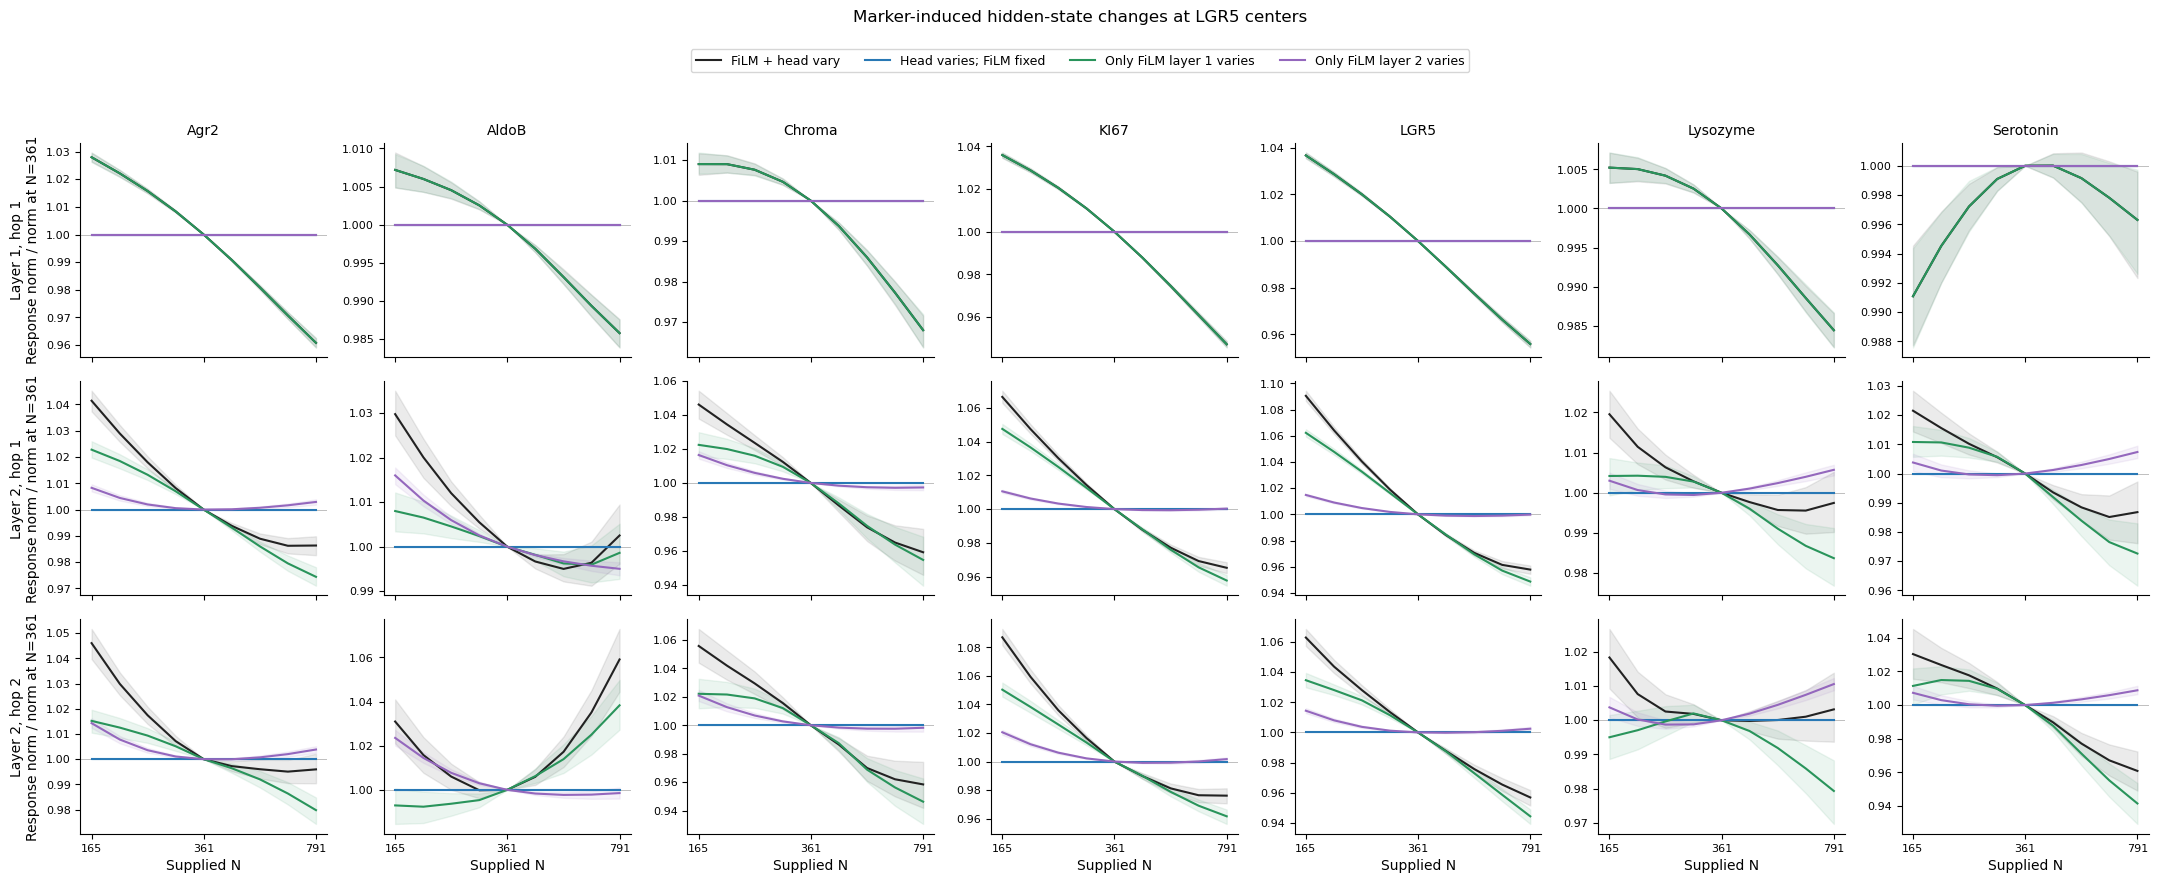

In [4]:
for lgr5_statistic in ['cosine','ratio']:
    lgr5_show_save(hidden_curves(lgr5_tables['effect_summary'], LGR5_MARKERS, LGR5_COUNTS,
        statistic=lgr5_statistic, minimum=LGR5_MIN_ORGANOIDS), f'hidden_response_{lgr5_statistic}')


### 4. Factorial marker interactions

For the same neighborhood and N, calculate

$$I=f_{-A,-B}-f_{-A}-f_{-B}+f_{\rm intact}.$$

Zero means additive removals on the chosen output scale; positive I means the joint
removal response is more positive than the sum of the single-removal responses.
Center–neighbor tests temporarily remove the center's LGR5 signal and one selected
neighbor marker. All centers were LGR5-positive originally. Neighbor–neighbor tests
keep the center unchanged and remove different markers on **distinct source cells in the
same hop**. The fixed manifest gives 4,745 center–neighbor tests and 5,204 neighbor-pair
tests per N/checkpoint coverage across folds. The 658 candidate pairs using the same
source cell are excluded. These are marker edits, not cell removal or fate conversion.

Transformed and normalized-curvature contrasts are both shown because the nonlinear
inverse target transform can create output non-additivity. The hidden contrast provides
an additional check before the head: its norm divided by the sum of the two single-edit
hidden norms. This unsigned ratio measures non-additivity, not whether curvature shifts
positively or negatively. No individual hidden channels are assigned cell-type meanings.


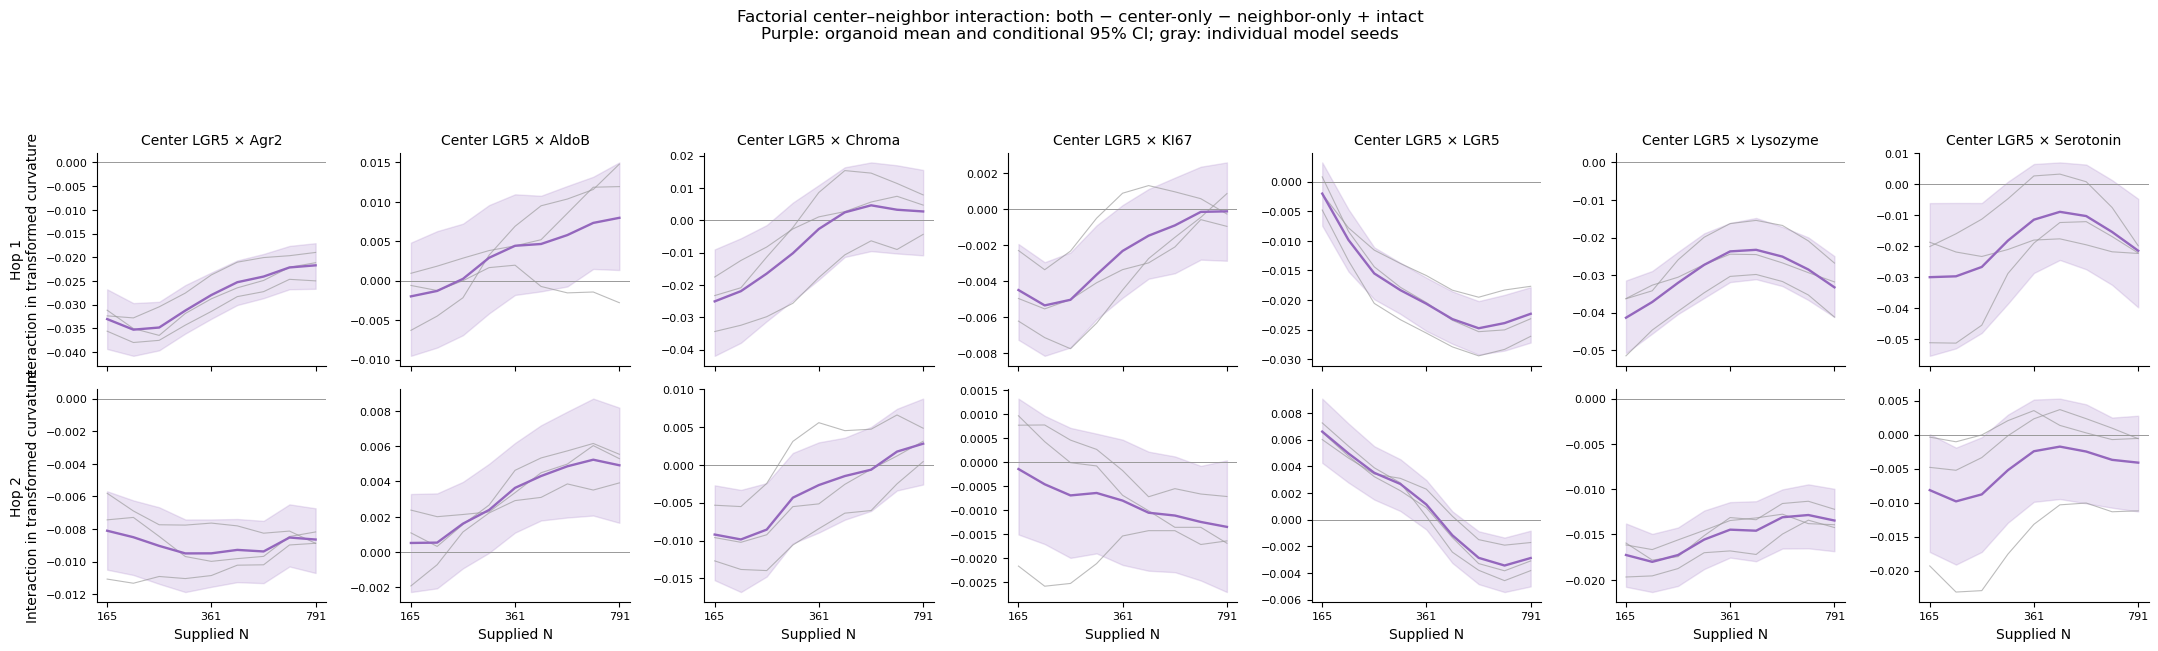

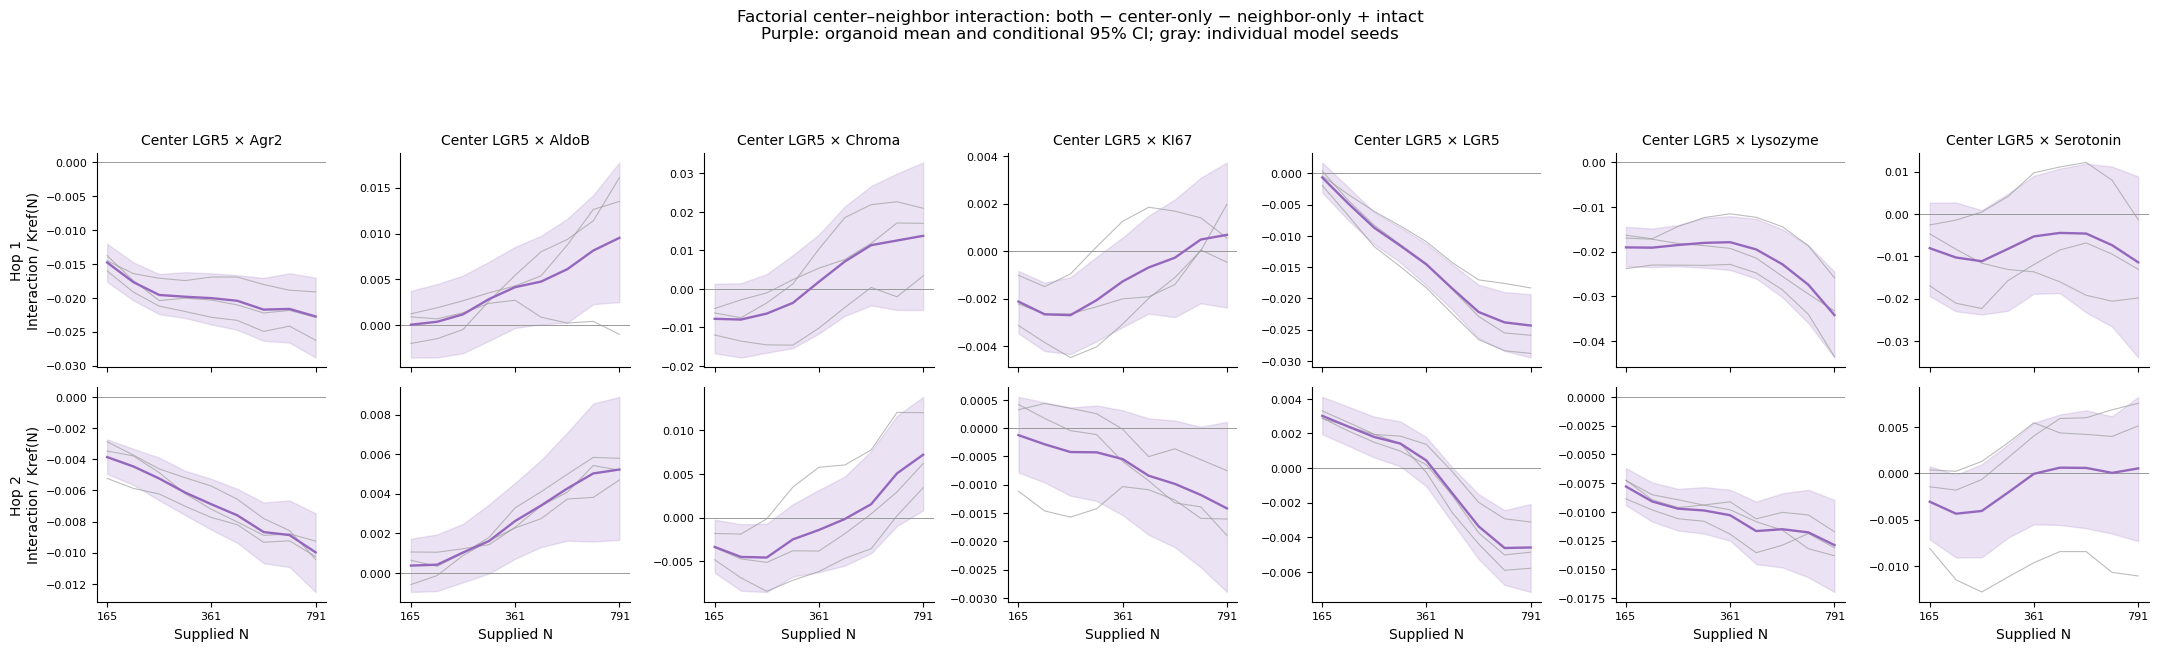

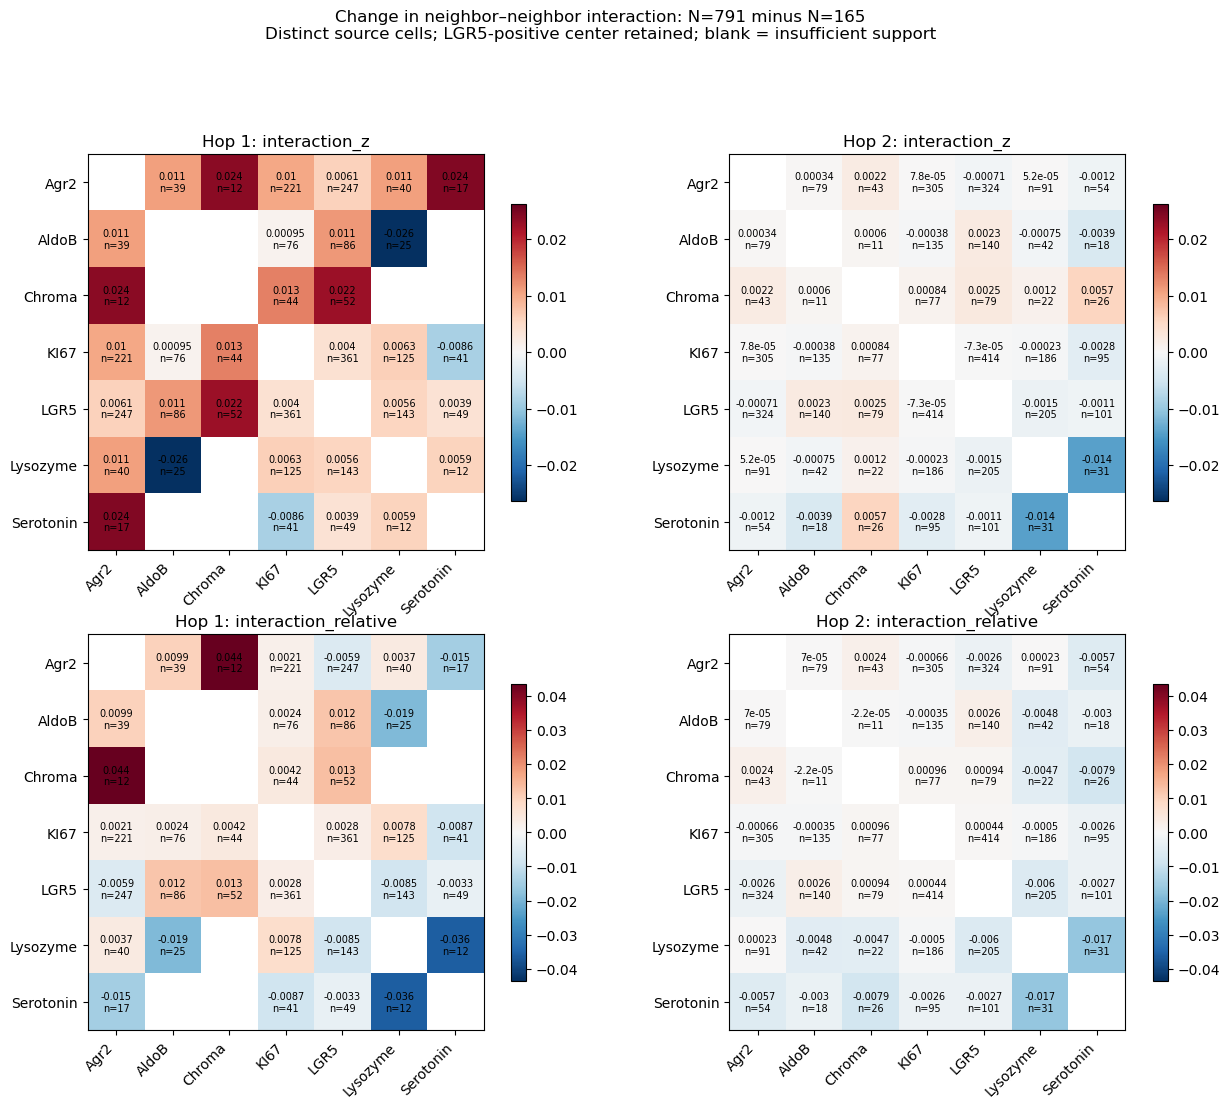

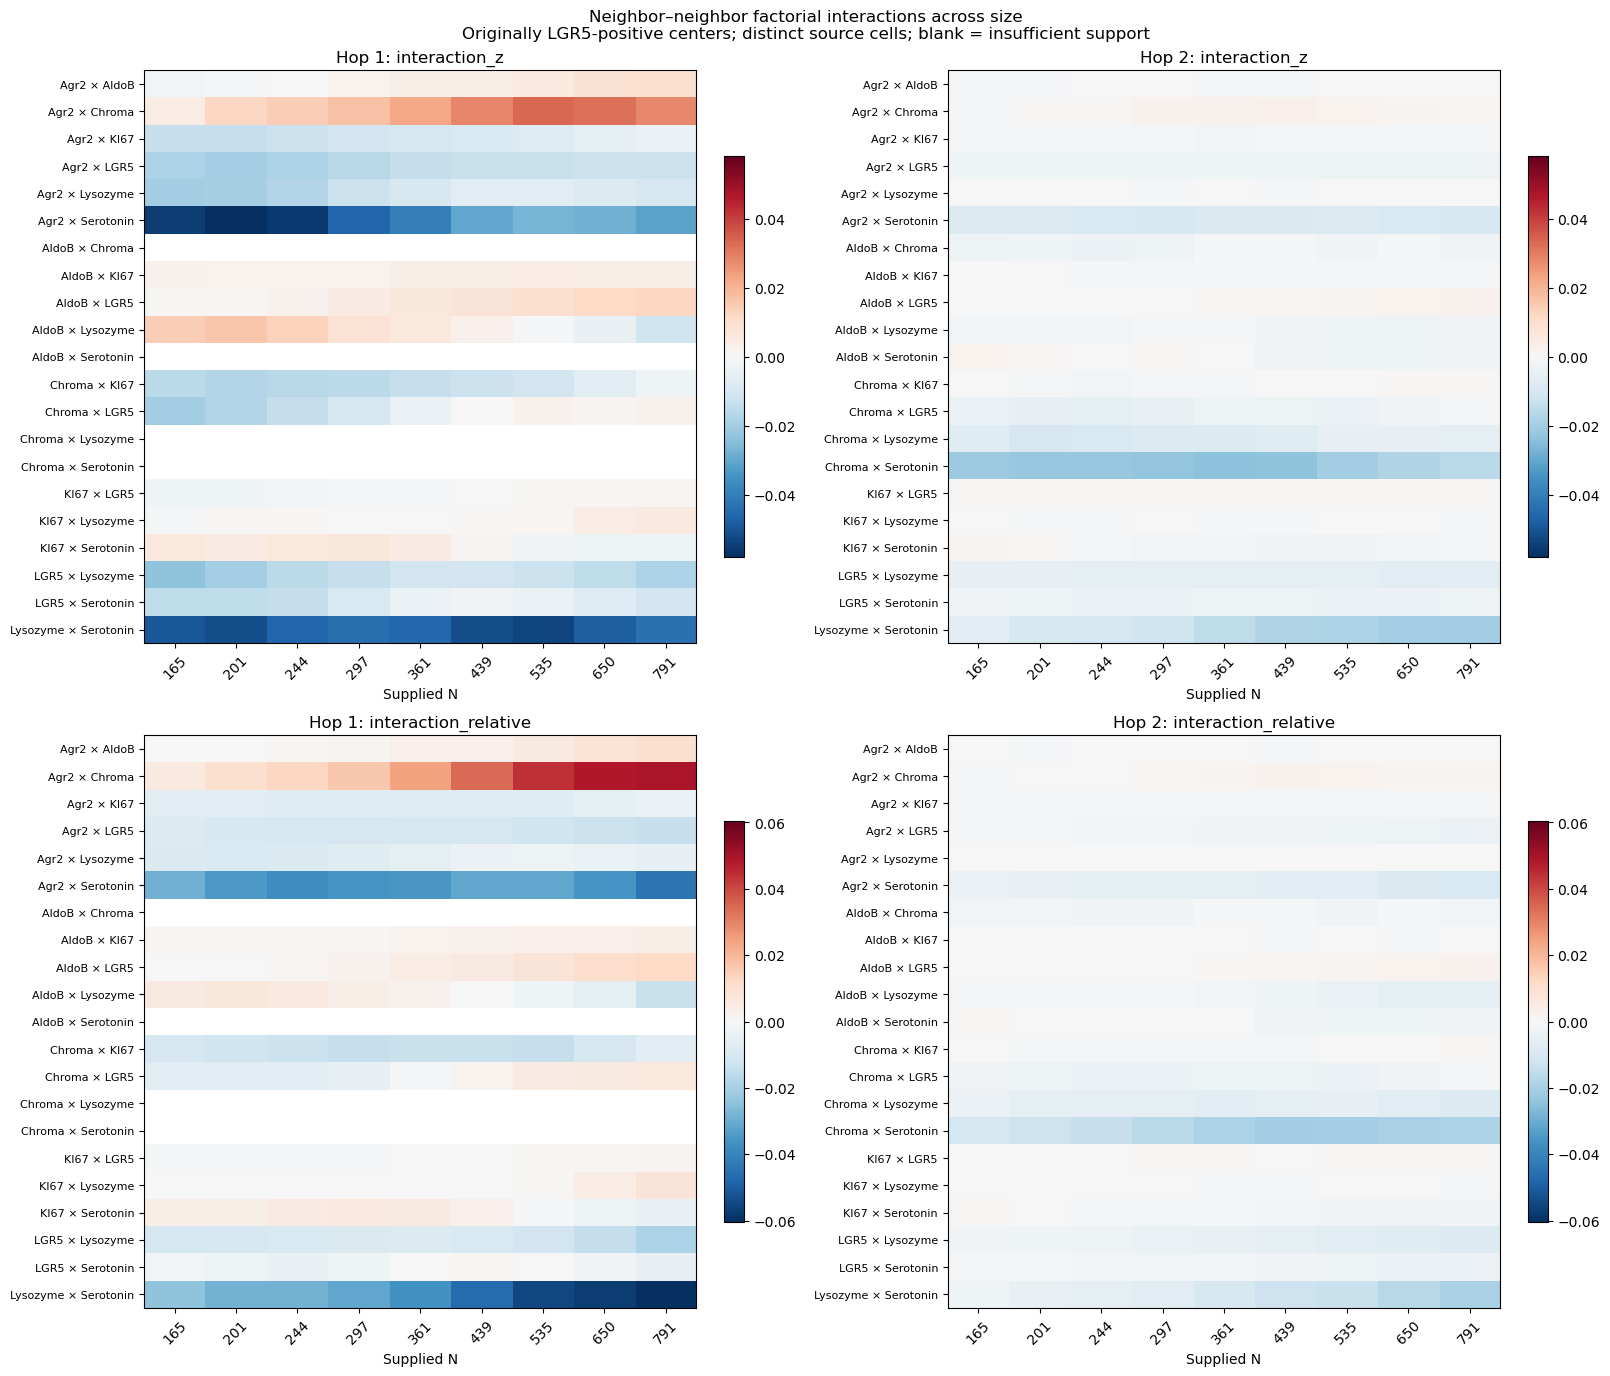

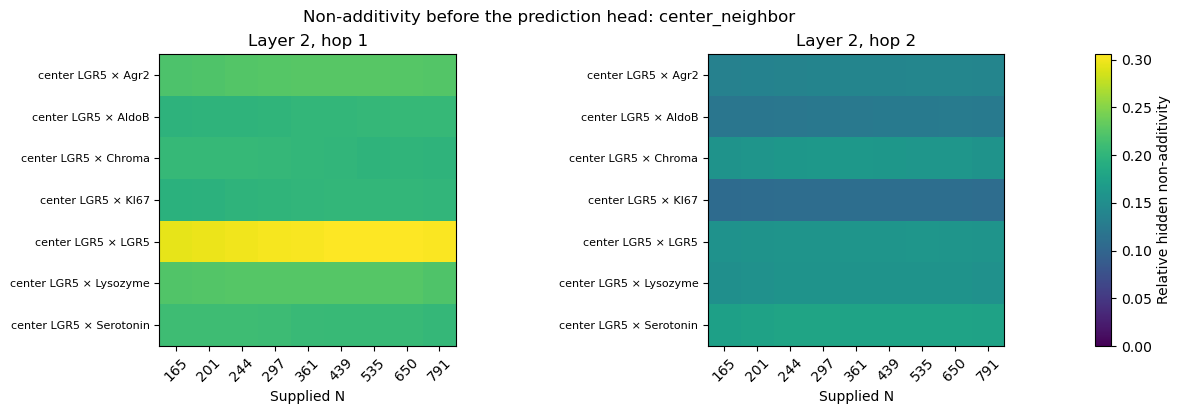

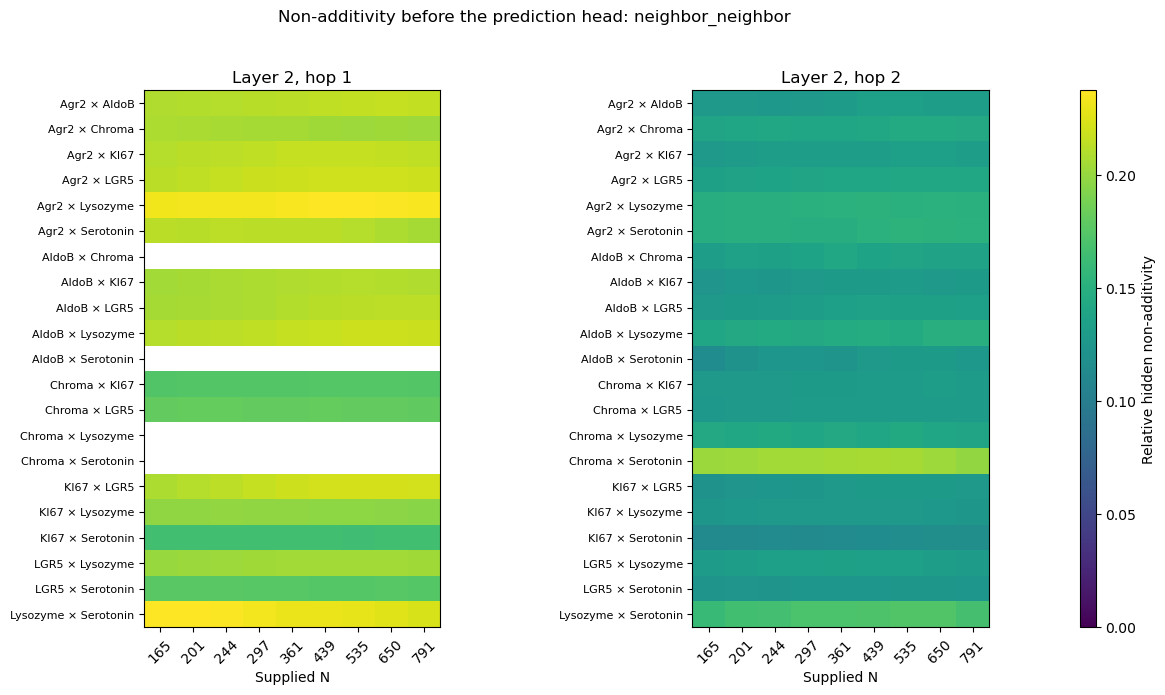

,kind,marker_a,marker_b,hop,metric,mean,ci_low,ci_high,n_organoids
0,center_neighbor,center LGR5,Agr2,1,interaction_z,0.011338,0.006087,0.016886,258
3,center_neighbor,center LGR5,Agr2,2,interaction_z,-0.000540,-0.002786,0.001902,330
6,center_neighbor,center LGR5,AldoB,1,interaction_z,0.009964,0.002750,0.017054,102
9,center_neighbor,center LGR5,AldoB,2,interaction_z,0.004401,0.001186,0.007657,147
12,center_neighbor,center LGR5,Chroma,1,interaction_z,0.027820,0.011576,0.043129,53
15,center_neighbor,center LGR5,Chroma,2,interaction_z,0.012022,0.007069,0.016982,80
18,center_neighbor,center LGR5,KI67,1,interaction_z,0.004369,0.001510,0.007207,420
21,center_neighbor,center LGR5,KI67,2,interaction_z,-0.001208,-0.002657,0.000253,446
24,center_neighbor,center LGR5,LGR5,1,interaction_z,-0.020300,-0.025453,-0.015287,448
27,center_neighbor,center LGR5,LGR5,2,interaction_z,-0.009485,-0.011665,-0.007406,452


,seed,kind,marker_a,marker_b,hop,interaction_z,interaction_raw,interaction_relative
0,42,center_neighbor,center LGR5,Agr2,1,0.013377,0.000446,-0.004601
4,42,center_neighbor,center LGR5,Chroma,1,0.022254,0.000977,0.022091
8,42,center_neighbor,center LGR5,LGR5,1,-0.015598,-0.000593,-0.017925
10,42,center_neighbor,center LGR5,Lysozyme,1,0.010340,0.000313,-0.019756
18,42,neighbor_neighbor,Agr2,KI67,1,0.008729,0.000273,0.001977
56,43,center_neighbor,center LGR5,Agr2,1,0.010613,0.000317,-0.010223
60,43,center_neighbor,center LGR5,Chroma,1,0.031144,0.001192,0.027154
64,43,center_neighbor,center LGR5,LGR5,1,-0.021335,-0.000836,-0.026889
66,43,center_neighbor,center LGR5,Lysozyme,1,0.009505,0.000350,-0.009508
74,43,neighbor_neighbor,Agr2,KI67,1,0.009385,0.000268,0.000472


In [3]:
for lgr5_metric in ['interaction_z','interaction_relative']:
    lgr5_show_save(center_interaction_curves(lgr5_tables['interaction_summary'],
        lgr5_tables['interaction_seed_summary'], LGR5_MARKERS, LGR5_COUNTS,
        metric=lgr5_metric, minimum=LGR5_MIN_ORGANOIDS), f'center_neighbor_{lgr5_metric}')
lgr5_show_save(neighbor_interaction_heatmap(lgr5_tables['interaction_endpoint_summary'],
    LGR5_MARKERS, minimum=LGR5_MIN_ORGANOIDS), 'neighbor_neighbor_endpoint_changes')
from src.plotting.lgr5_film import neighbor_interaction_size_heatmap
lgr5_show_save(neighbor_interaction_size_heatmap(lgr5_tables['interaction_summary'], LGR5_COUNTS,
    minimum=LGR5_MIN_ORGANOIDS), 'neighbor_neighbor_interactions_across_N')
for lgr5_kind in ['center_neighbor','neighbor_neighbor']:
    lgr5_show_save(hidden_interaction_heatmap(lgr5_tables['interaction_summary'],LGR5_COUNTS,
        kind=lgr5_kind,minimum=LGR5_MIN_ORGANOIDS), f'hidden_nonadditivity_{lgr5_kind}')
display(lgr5_tables['interaction_endpoint_summary'].query(
    "metric == 'interaction_z' and kind == 'center_neighbor'"))
display(lgr5_tables['interaction_endpoint_seeds'].query(
    "hop == 1 and ((kind == 'center_neighbor' and marker_b in ['LGR5','Agr2','Chroma','Lysozyme']) or (kind == 'neighbor_neighbor' and marker_a == 'Agr2' and marker_b == 'KI67'))"))


### Brief report

The report below describes this saved run. Figures, pointwise and paired-endpoint summaries,
seed summaries, common-support counts, inference manifests, and per-case diagnostic tables
are saved under the run's `lgr5_film_diagnostics` directory.


In [6]:
display(Markdown((LGR5_OUTPUT_DIR / 'REPORT.md').read_text()))


# FiLM interactions around LGR5-positive centers

**The trained FiLM model changes relative marker sensitivities with N; its behavior is not explained by a common response multiplier or by the head's explicit size input alone.** This is evidence about the model's computation, not causal biological interactions.

We analyzed the completed, sphericity-filtered run `20260910_164825_all_depth2_four_models_baseline_with_size`, using the FiLM model without geometry in the head. No training was repeated. The sample contains **767 originally LGR5-positive centers from 461 validation organoids**, five folds, three seeds, and nine supplied counts from 165 to 791. All diagnostic routes are anchored at **N=361**. Centers can coexpress markers; 293 centers express LGR5 alone and 474 also express KI67 and/or AldoB.

## Main findings

**1. Marker preference changes beyond common scaling.** On 166 centers from 143 organoids containing both selected neighboring LGR5 and Lysozyme signals, a common positive multiplier of the N=361 response leaves **42.6% of the response-vector norm unexplained at N=165** in transformed curvature. This is 41.9% when only FiLM varies, versus 0.20% when only the head's size input varies. The full-route mismatch is 37.9–51.6% across the three seeds. Geometric normalization gives a similar full-route mismatch, 43.4%. These are norm fractions, not explained-variance statistics; the common-scaling fit and its signed residuals are recomputed inside paired organoid bootstraps.

**2. FiLM accounts for most of the size dependence in the two clearest marker responses.** The table gives the change in the single-marker ablation effect from N=165 to N=791, in transformed-curvature units. Positive means that the ablation effect becomes more positive between endpoints; it does not imply a monotonic curve.

| Size inputs varied | Neighbor LGR5, hop 1 | Neighbor Lysozyme, hop 1 |
| --- | ---: | ---: |
| FiLM and head | +0.0394 | −0.0689 |
| FiLM only | +0.0374 | −0.0736 |
| Head only | +0.00220 | +0.00432 |
| FiLM layer 1 only | +0.0235 | −0.0642 |
| FiLM layer 2 only | +0.0101 | −0.0122 |

The LGR5 and Lysozyme full/FiLM-only endpoint signs agree across all three seeds. Layer 1 consistently makes a large contribution to Lysozyme sensitivity; layer 2's isolated Lysozyme contribution is more seed-dependent and changes sign in one seed. Routes are nonlinear interventions and should not be added or interpreted as additive percentages. Individual-marker cohorts contain 448 and 148 organoids, respectively; the matched comparison above uses their common eligible centers.

**3. Hidden responses change direction, not just magnitude.** At N=791, the mean cosine similarity of the LGR5-ablation response to its N=361 direction is **0.839 after layer 2 for hop 1**, and **0.741 for hop 2**. Head-only sweeps leave these representations unchanged within numerical precision. This locates changes before the head, although hidden axes themselves have no assigned biological meanings.

**4. Some explicit marker couplings change with N.** For the factorial contrast `both removed − A removed − B removed + intact`, the center-LGR5 × neighbor-LGR5 hop-1 interaction changes by **−0.0203** between endpoints (conditional 95% CI −0.0255 to −0.0153; all seeds negative). Center-LGR5 × Agr2 changes by **+0.0113** (CI +0.00609 to +0.0169; all seeds positive). Among distinct neighboring cells, Agr2 × KI67 changes by **+0.0103** (CI +0.00735 to +0.0131; 221 organoids; all seeds positive).

Strong size dependence of a single-marker effect does not automatically mean its coupling to center LGR5 changes reliably: the Lysozyme center-interaction endpoint contrast is +0.00810, with CI −0.00156 to +0.0178. Hidden mixed differences are already nonzero before the head, but their relative norms can be fairly stable with N—for center/neighbor LGR5 at hop 1, approximately 0.29–0.30. A changing curvature interaction therefore need not reflect a similarly large change in the norm of the hidden interaction.

## Interpretation and checks

The evidence supports size-dependent marker processing within this model. It does not identify physical cell–cell mechanisms. Mixed FiLM/head inputs and marker removals are internal network diagnostics; small-support pairs and multiple exploratory comparisons need caution. Pointwise intervals condition on fitted models and geometric references and do not include retraining uncertainty. Seed results and matched support are exported separately. Curvature normalization and the inverse target transform can change output-scale interactions, so transformed and pre-head analyses are retained.

All 15 checkpoints completed: 4,745 fixed single-marker/center-factorial cases and 5,204 distinct-cell neighbor-pair cases across folds, repeated across N and seeds. The 658 same-source-cell neighbor candidates were excluded. Full-route ablation effects reproduce the saved experiment with maximum absolute difference **6.56×10⁻⁸**. Unit checks verify route separation, restoration of the original forward behavior, nonmutation, factorial contrasts, and common-scaling calculations. Figures and the underlying case, support, bootstrap, and seed tables are saved beside this report and displayed in the notebook's **FiLM interactions around LGR5-positive centers** section.
